In [1]:
# =========================
# Standard library imports
# =========================
import sys
import os
import io
import gzip
from pathlib import Path
import math
import json
import pickle
import logging
import random
import subprocess
import warnings
import collections
import itertools
import re
from IPython.display import display

warnings.filterwarnings("ignore")


# =========================
# Numeric / stats
# =========================
import numpy as np
import pandas as pd
from scipy import sparse
from scipy import stats
from scipy.stats import rankdata
from scipy import __version__ as scipy_version


# =========================
# Plotting / visualization
# =========================
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FormatStrFormatter, MaxNLocator
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import seaborn as sns


# =========================
# scikit-learn
# =========================
from sklearn import model_selection, metrics
from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit,
    KFold,
    GroupKFold,
    cross_val_score,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import LocalOutlierFactor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)
from sklearn import __version__ as sklearn_version


# =========================
# Optimization / AutoML
# =========================
import optuna


# =========================
# LightGBM
# =========================
try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
    _HAS_LGBM = True
except Exception as e:
    _HAS_LGBM = False
    raise RuntimeError(
        "LightGBM not installed. Please install it with `pip install lightgbm`."
    ) from e


# =========================
# RNA structure (ViennaRNA)
# =========================
import RNA


# =========================
# UpSet plots
# =========================
try:
    from upsetplot import UpSet, from_memberships
except Exception:
    _ = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "upsetplot"],
        check=False,
    )
    from upsetplot import UpSet, from_memberships


# =========================
# Model explanation
# =========================
import shap


# =========================
# User-provided utilities
# =========================
import sylib  


# =========================
# Version info
# =========================
print(f"python    = {sys.version_info[0]}.{sys.version_info[1]}.{sys.version_info[2]}")
print(f"pandas    = {pd.__version__}")
print(f"numpy     = {np.__version__}")
print(f"scipy     = {scipy_version}")
print(f"optuna    = {optuna.__version__}")
print(f"sklearn   = {sklearn_version}")
print(f"ViennaRNA = {RNA.__version__}")
print(f"lightgbm  = {lgb.__version__}")
print(f"sylib     = {sylib.__version__}")


# =========================
# Progress bar & logging
# =========================
# progress bar from sylib
progress_bar = sylib.utils.ProgressBar()

# reset handlers then configure logging
logging.root.handlers = []
stream_handler = logging.StreamHandler(sys.stderr)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler],
)
logger = logging.getLogger(__name__)

# make matplotlib quieter
logging.getLogger("matplotlib").setLevel(logging.WARNING)

python    = 3.11.15
pandas    = 2.3.3
numpy     = 2.4.6
scipy     = 1.17.1
optuna    = 4.9.0
sklearn   = 1.9.0
ViennaRNA = 2.7.2
lightgbm  = 4.6.0
sylib     = 0.3.0.dev0+ae18bb2


In [3]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 6.0,
    "dpi": 300,
}


SPECIES_INFO = {
    "AT21": {
        "label": "AT",
        "short": "AT21",
        "color": "#664D0AFF",
        "marker": "o",
    },
    "NB21": {
        "label": "NB",
        "short": "NB21",
        "color": "#7e3131",
        "marker": "^",
    },
    "OS21": {
        "label": "OS",
        "short": "OS21",
        "color": "#13563f",
        "marker": "s",
    },
}

def set_plot_style(
    *,
    base_fontsize=10,
    title_fontsize=12,
    label_fontsize=10,
    tick_fontsize=9,
    legend_fontsize=10,
    dpi=300,
    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,
    tick_size_major=6,
    tick_dir="out",
    grid=False,
    fig_w=6.0,
    fig_h=6.0,
):
    sns.set_style("ticks")

    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        "legend.frameon": False,

        "savefig.bbox": "tight",
        "savefig.transparent": False,
        "figure.autolayout": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(w=None, h=None, dpi=None):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


def _compact_formatter():
    def _fmt(x, _pos=None):
        axx = abs(x)

        if axx >= 1e9:
            s = f"{x / 1e9:.1f}B"
        elif axx >= 1e6:
            s = f"{x / 1e6:.1f}M"
        elif axx >= 1e3:
            s = f"{x / 1e3:.1f}k"
        else:
            s = f"{x:.2g}"

        return (
            s.replace(".0B", "B")
             .replace(".0M", "M")
             .replace(".0k", "k")
        )

    return FuncFormatter(_fmt)


def format_axis(
    ax,
    *,
    xlabel=None,
    ylabel=None,
    compact_ticks=(),
):
    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    fmt = _compact_formatter()

    if "x" in compact_ticks:
        ax.xaxis.set_major_formatter(fmt)

    if "y" in compact_ticks:
        ax.yaxis.set_major_formatter(fmt)

    return ax


# ============================================
# Joint scatter with KDE marginals
# ============================================

def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.pearsonr(x, y)


def safe_spearmanr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.spearmanr(x, y)

def _kde_1d(values, lo, hi, num=256):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    grid = np.linspace(lo, hi, num)

    if len(values) < 2:
        return grid, np.zeros_like(grid)

    try:
        kde = stats.gaussian_kde(values)
        dens = kde(grid)
        dens /= dens.max() if dens.max() > 0 else 1
        return grid, dens

    except Exception:
        return grid, np.zeros_like(grid)


def joint_scatter(
    x,
    y,
    *,
    color=None,
    point_size=18,
    alpha=0.65,
    show_identity=True,
    show_regression=True,
    annotate=True,
    annotate_spearman=True,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=None,
    w=None,
    h=None,
    dpi=None,
    annotate_fontsize=14,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    n = len(x)

    if figsize is not None:
        FW, FH = figsize
    else:
        FW = float(w) if w is not None else _PLOT_CFG["fig_w"]
        FH = float(h) if h is not None else _PLOT_CFG["fig_h"]

    fig = plt.figure(
        figsize=(FW, FH),
        dpi=(dpi or _PLOT_CFG["dpi"]),
    )

    gs = GridSpec(
        2,
        2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        hspace=0.05,
        wspace=0.05,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    ax_joint.scatter(
        x,
        y,
        s=point_size,
        alpha=alpha,
        edgecolor="none",
        color=color,
    )

    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))

    pad = 0.05 * (hi - lo if hi > lo else 1.0)

    lo -= pad
    hi += pad

    ax_joint.set_xlim(lo, hi)
    ax_joint.set_ylim(lo, hi)

    if show_identity:
        ax_joint.plot(
            [lo, hi],
            [lo, hi],
            ls="--",
            lw=1.2,
            color="0.65",
            zorder=1,
        )

    if show_regression and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        slope, intercept = np.polyfit(x, y, 1)

        ax_joint.plot(
            [lo, hi],
            slope * np.array([lo, hi]) + intercept,
            color="black",
            lw=1.5,
            zorder=2,
        )

    format_axis(
        ax_joint,
        xlabel=xlabel,
        ylabel=ylabel,
        compact_ticks=(),
    )

    if title:
        ax_joint.set_title(title)

    if annotate and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rp, _ = safe_pearsonr(x, y)
        rs, _ = safe_spearmanr(x, y)

        txt = rf"$r_p = {rp:.2f}$"

        if annotate_spearman:
            txt += "\n" + rf"$r_s = {rs:.2f}$"

        txt += f"\n$n = {n}$"

        ax_joint.text(
            0.04,
            0.96,
            txt,
            transform=ax_joint.transAxes,
            ha="left",
            va="top",
            fontsize=annotate_fontsize,
        )

    gx, dx = _kde_1d(x, lo, hi)
    gy, dy = _kde_1d(y, lo, hi)

    ax_top.plot(gx, dx, lw=2, color=color)
    ax_top.axis("off")

    ax_right.plot(dy, gy, lw=2, color=color)
    ax_right.axis("off")

    plt.tight_layout()

    return fig, (ax_joint, ax_top, ax_right)


set_plot_style()

# ============================================
# Plot helper functions
# ============================================

def species_palette():
    return [
        SPECIES_INFO["AT21"]["color"],
        SPECIES_INFO["NB21"]["color"],
        SPECIES_INFO["OS21"]["color"],
    ]


def outside_legend(
    ax,
    *,
    title="Species",
    n_items=3,
    x=1.02,
    y=1.00,
):
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:n_items],
        labels[:n_items],
        title=title,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(x, y),
        borderaxespad=0,
    )

    return ax

In [4]:
# ============================================
# 01. Load locked selected-feature dataset
# ============================================

RESULT_DIR = Path("/mnt/d/Ibnu/Programming/data/regression/results/lgbm")
SPECIES_KEYS = ["AT21", "NB21", "OS21"]
SPECIES_ORDER = ["AT", "NB", "OS"]

# Locked FI + SSS selection
candidate_all_df = pd.read_csv(
    RESULT_DIR / "lgbm.species_specific_candidate_table.importance_p90.sss_p90.tsv.gz",
    sep="\t",
)

candidate_selected_df = candidate_all_df.loc[candidate_all_df["Selected"]].copy()
candidate_features = sorted(candidate_selected_df["Feature"].unique())

# Feature metadata + selection origin
feature_metadata_df = (
    candidate_selected_df[["Feature", "Region", "Feature_type"]]
    .drop_duplicates()
    .sort_values("Feature")
)

selection_origin_df = (
    pd.crosstab(candidate_selected_df["Feature"], candidate_selected_df["Species"])
    .reindex(columns=SPECIES_ORDER, fill_value=0)
    .gt(0)
    .add_prefix("Selected_")
    .reset_index()
)

feature_metadata_df = (
    feature_metadata_df
    .merge(selection_origin_df, on="Feature", validate="one_to_one")
    .reset_index(drop=True)
)

# Raw biological data for the 61-feature union
raw_rows = []

for species_key in SPECIES_KEYS:
    species = SPECIES_INFO[species_key]["label"]

    with gzip.open(RESULT_DIR / f"{species_key}.lgbm.data_bundle.pkl.gz", "rb") as f:
        bundle = pickle.load(f)

    assert bundle["species"] == species_key
    assert set(candidate_features).issubset(bundle["feature_names"])

    metadata = pd.concat([bundle["train_metadata"], bundle["test_metadata"]])
    x_raw = pd.concat([bundle["x_train_raw"], bundle["x_test_raw"]])[candidate_features]

    assert metadata.index.equals(x_raw.index)

    temp = pd.concat([metadata, x_raw], axis=1)
    temp.insert(0, "Species", species)
    raw_rows.append(temp)

candidate_master_df = pd.concat(raw_rows, ignore_index=True)

# Sanity checks
selected_count_df = (
    candidate_selected_df.groupby("Species").size()
    .reindex(SPECIES_ORDER)
    .rename("N_selected")
    .reset_index()
)

assert dict(zip(selected_count_df["Species"], selected_count_df["N_selected"])) == {
    "AT": 19, "NB": 28, "OS": 23
}
assert len(candidate_features) == 61
assert feature_metadata_df["Feature"].is_unique
assert set(feature_metadata_df["Feature"]) == set(candidate_features)
assert candidate_master_df[candidate_features].isna().sum().sum() == 0

print("Selected rows:", len(candidate_selected_df))
print("Unique features:", len(candidate_features))
print("Raw data shape:", candidate_master_df.shape)

display(selected_count_df)
display(feature_metadata_df.head())

Selected rows: 70
Unique features: 61
Raw data shape: (18059, 69)


,Species,N_selected
0,AT,19
1,NB,28
2,OS,23


,Feature,Region,Feature_type,Selected_AT,Selected_NB,Selected_OS
0,3'UTR.ACA-freq,3'UTR,Nucleotide_kmer_freq,False,True,False
1,3'UTR.AG-freq,3'UTR,Nucleotide_kmer_freq,False,True,False
2,3'UTR.AUC-freq,3'UTR,Nucleotide_kmer_freq,False,True,False
3,3'UTR.G-freq,3'UTR,Nucleotide_kmer_freq,False,True,False
4,3'UTR.GAU-freq,3'UTR,Nucleotide_kmer_freq,True,False,False


In [7]:
# ============================================
# 02. PR association for 61 selected features
# ============================================

from scipy.stats import spearmanr, pearsonr

rows = []

for feature in candidate_features:
    meta = feature_metadata_df.loc[
        feature_metadata_df["Feature"].eq(feature)
    ].iloc[0]

    for species in SPECIES_ORDER:
        d = candidate_master_df.loc[
            candidate_master_df["Species"].eq(species),
            [feature, "observed_raw"],
        ].dropna()

        rho, p_rho = spearmanr(d[feature], d["observed_raw"])
        r, p_r = pearsonr(d[feature], d["observed_raw"])

        rows.append({
            "Feature": feature, "Region": meta["Region"],
            "Feature_type": meta["Feature_type"], "Species": species,
            "N": len(d), "Spearman_rho": rho, "Spearman_p": p_rho,
            "Pearson_r": r, "Pearson_p": p_r,
        })

feature_pr_df = pd.DataFrame(rows)

spearman_matrix = (
    feature_pr_df.pivot(index="Feature", columns="Species", values="Spearman_rho")
    .reindex(index=candidate_features, columns=SPECIES_ORDER)
)

pearson_matrix = (
    feature_pr_df.pivot(index="Feature", columns="Species", values="Pearson_r")
    .reindex(index=candidate_features, columns=SPECIES_ORDER)
)

assert feature_pr_df.shape[0] == 183
assert spearman_matrix.shape == (61, 3)
assert pearson_matrix.shape == (61, 3)

print("Association rows:", len(feature_pr_df))
print("Spearman matrix:", spearman_matrix.shape)
print("Pearson matrix:", pearson_matrix.shape)

display(feature_pr_df.head(9))
display(spearman_matrix.head())

Association rows: 183
Spearman matrix: (61, 3)
Pearson matrix: (61, 3)


,Feature,Region,Feature_type,Species,N,Spearman_rho,Spearman_p,Pearson_r,Pearson_p
0,3'UTR.ACA-freq,3'UTR,Nucleotide_kmer_freq,AT,7126,-0.072641,8.302206e-10,-0.075542,1.714455e-10
1,3'UTR.ACA-freq,3'UTR,Nucleotide_kmer_freq,NB,5381,-0.038846,4.371864e-03,-0.037803,5.547453e-03
2,3'UTR.ACA-freq,3'UTR,Nucleotide_kmer_freq,OS,5552,-0.018380,1.708921e-01,-0.011864,3.767826e-01
3,3'UTR.AG-freq,3'UTR,Nucleotide_kmer_freq,AT,7126,-0.021218,7.329550e-02,-0.019969,9.188541e-02
4,3'UTR.AG-freq,3'UTR,Nucleotide_kmer_freq,NB,5381,-0.048157,4.096035e-04,-0.054204,6.944467e-05
5,3'UTR.AG-freq,3'UTR,Nucleotide_kmer_freq,OS,5552,0.065712,9.560175e-07,0.064073,1.770506e-06
6,3'UTR.AUC-freq,3'UTR,Nucleotide_kmer_freq,AT,7126,-0.018981,1.091130e-01,-0.006615,5.766496e-01
7,3'UTR.AUC-freq,3'UTR,Nucleotide_kmer_freq,NB,5381,-0.009030,5.078244e-01,0.007008,6.072935e-01
8,3'UTR.AUC-freq,3'UTR,Nucleotide_kmer_freq,OS,5552,-0.026988,4.434644e-02,-0.017318,1.969811e-01


Species,AT,NB,OS
Feature,,,
3'UTR.ACA-freq,-0.072641,-0.038846,-0.018380
3'UTR.AG-freq,-0.021218,-0.048157,0.065712
3'UTR.AUC-freq,-0.018981,-0.009030,-0.026988
3'UTR.G-freq,0.030630,-0.036839,0.037134
3'UTR.GAU-freq,-0.019663,-0.016343,0.018831


,Pair,Spearman,Pearson
0,AT–NB,0.532,0.482
1,AT–OS,0.570,0.573
2,NB–OS,0.552,0.765


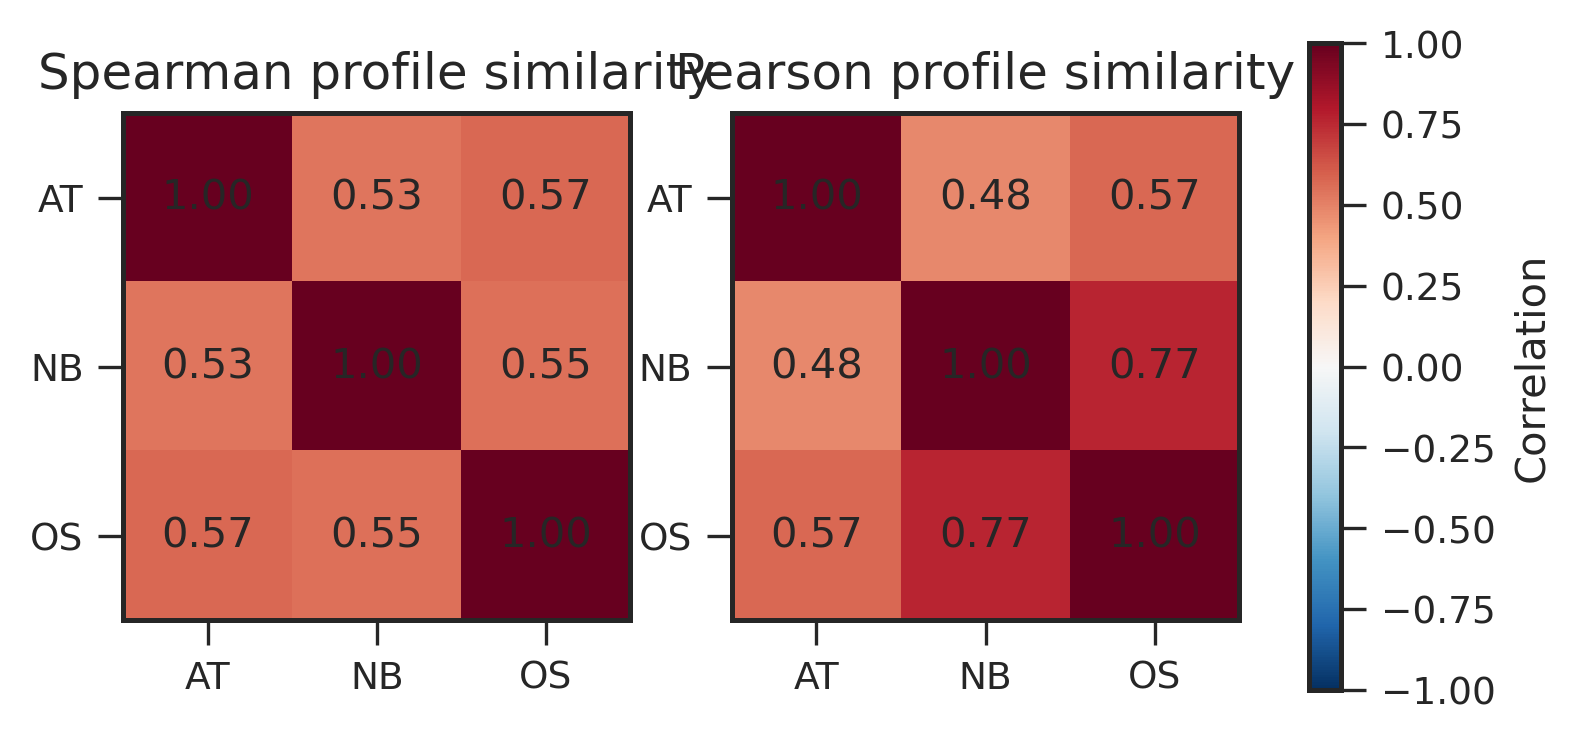

In [21]:
# ============================================
# 03. Cross-species PR-profile similarity
# ============================================

species_profile_rho = spearman_matrix.corr(method="spearman")
species_profile_r = spearman_matrix.corr(method="pearson")

profile_similarity_df = pd.DataFrame([
    {"Pair": f"{a}–{b}",
     "Spearman": species_profile_rho.loc[a, b],
     "Pearson": species_profile_r.loc[a, b]}
    for i, a in enumerate(SPECIES_ORDER)
    for b in SPECIES_ORDER[i + 1:]
])

display(profile_similarity_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(6, 2.8), dpi=_PLOT_CFG["dpi"])

for ax, mat, title in zip(
    axes, [species_profile_rho, species_profile_r],
    ["Spearman profile similarity", "Pearson profile similarity"]
):
    im = ax.imshow(mat.astype(float), vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(3), SPECIES_ORDER)
    ax.set_yticks(range(3), SPECIES_ORDER)
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{mat.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=axes, label="Correlation")
plt.show()

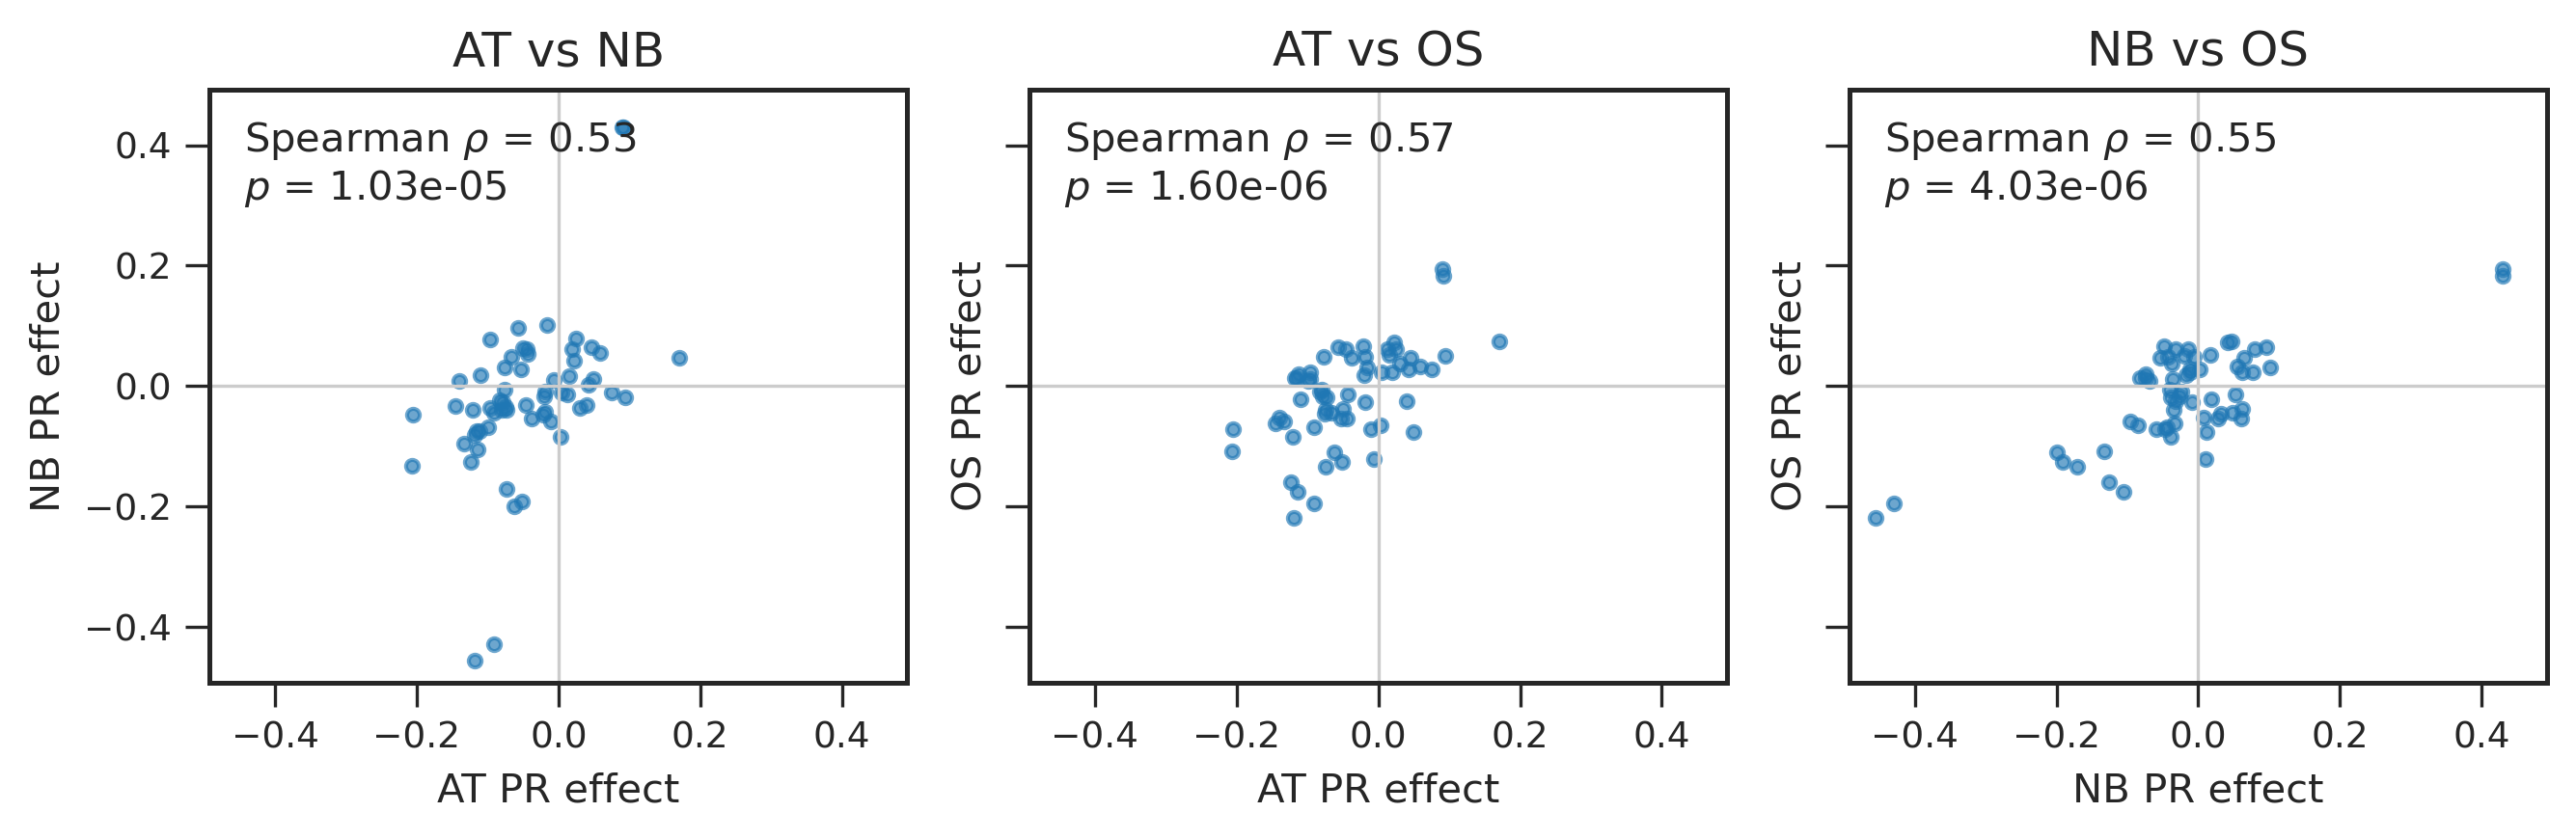

In [24]:
# ============================================
# 03. Pairwise cross-species PR effects
# ============================================

from scipy.stats import spearmanr

pairs = [("AT", "NB"), ("AT", "OS"), ("NB", "OS")]
fig, axes = plt.subplots(1, 3, figsize=(9, 3), dpi=_PLOT_CFG["dpi"], sharex=True, sharey=True)

lim = np.abs(spearman_matrix.to_numpy()).max() * 1.08

for ax, (x, y) in zip(axes, pairs):
    a, b = spearman_matrix[x], spearman_matrix[y]
    rho, p = spearmanr(a, b)

    ax.scatter(a, b, s=10, alpha=.65)
#     ax.plot([-lim, lim], [-lim, lim], ls="--", lw=1, color="0.65")
    ax.axhline(0, lw=.8, color="0.8")
    ax.axvline(0, lw=.8, color="0.8")

    ax.set(title=f"{x} vs {y}", xlabel=f"{x} PR effect", ylabel=f"{y} PR effect",
           xlim=(-lim, lim), ylim=(-lim, lim))
    ax.text(.05, .95, rf"Spearman $\rho$ = {rho:.2f}" + f"\n$p$ = {p:.2e}",
            transform=ax.transAxes, va="top")

plt.tight_layout()
plt.show()

,Feature,AT,NB,OS,Mean_rho,Range_rho,SD_rho,Region,Feature_type,Selected_AT,Selected_NB,Selected_OS
0,CDS.aa_pct_X,0.091,0.429,0.195,0.238,0.338,0.173,CDS,Amino_acid_composition,False,True,False
1,CDS.Length,-0.091,-0.429,-0.195,-0.238,0.338,0.173,CDS,Length,False,True,True
2,mRNA.MFE,0.091,0.430,0.183,0.235,0.338,0.175,mRNA,RNA_structure_MFE,True,True,False
3,mRNA.Length,-0.119,-0.456,-0.220,-0.265,0.337,0.173,mRNA,Length,False,True,True
4,mRNA.AUA-freq,-0.096,0.077,0.023,0.002,0.173,0.089,mRNA,Nucleotide_kmer_freq,True,False,False
5,CDS.AU-freq,-0.205,-0.047,-0.071,-0.108,0.158,0.085,CDS,Nucleotide_kmer_freq,True,False,False
6,mRNA.UAG-freq,-0.056,0.097,0.065,0.035,0.153,0.081,mRNA,Nucleotide_kmer_freq,True,False,False
7,5'UTR.S-freq,-0.140,0.008,-0.052,-0.061,0.148,0.075,5'UTR,Nucleotide_kmer_freq,True,False,False
8,mRNA.CC-freq,-0.051,-0.192,-0.127,-0.123,0.140,0.070,mRNA,Nucleotide_kmer_freq,False,True,False
9,mRNA.C-freq,-0.062,-0.199,-0.110,-0.124,0.137,0.070,mRNA,Nucleotide_kmer_freq,False,True,False


,Range_rho,SD_rho
count,61.000,61.000
mean,0.107,0.055
std,0.072,0.037
min,0.018,0.009
25%,0.062,0.033
50%,0.098,0.051
75%,0.126,0.065
max,0.338,0.175


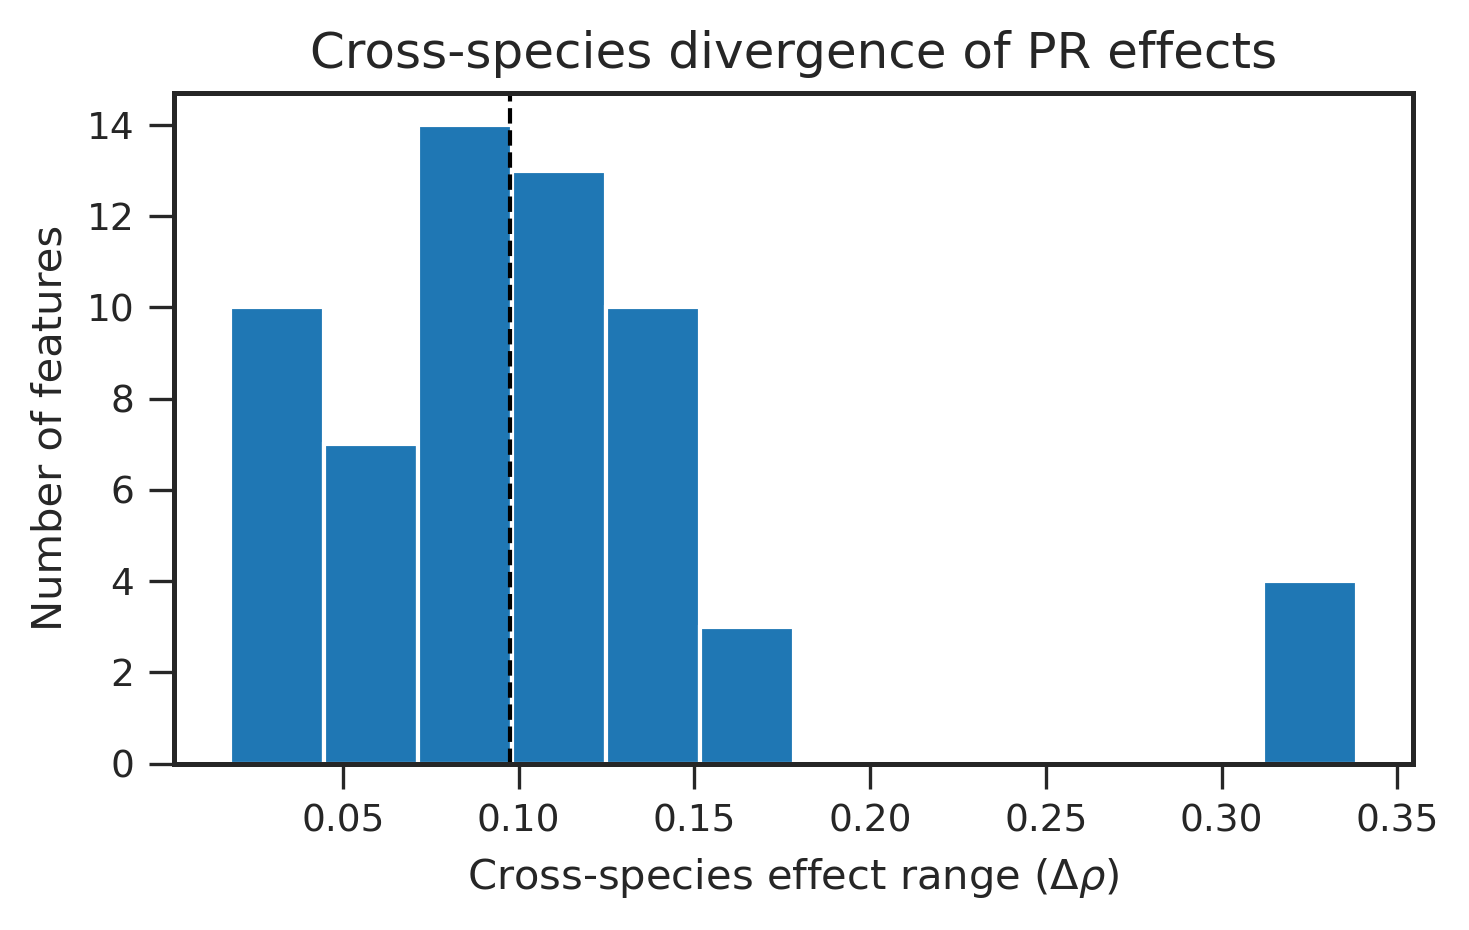

In [25]:
# ============================================
# 04. Feature-level cross-species divergence
# ============================================

effect_divergence_df = spearman_matrix.copy()
effect_divergence_df["Mean_rho"] = effect_divergence_df[SPECIES_ORDER].mean(axis=1)
effect_divergence_df["Range_rho"] = (
    effect_divergence_df[SPECIES_ORDER].max(axis=1)
    - effect_divergence_df[SPECIES_ORDER].min(axis=1)
)
effect_divergence_df["SD_rho"] = effect_divergence_df[SPECIES_ORDER].std(axis=1)

effect_divergence_df = (
    effect_divergence_df.reset_index()
    .merge(feature_metadata_df, on="Feature", how="left")
    .sort_values("Range_rho", ascending=False)
    .reset_index(drop=True)
)

display(effect_divergence_df.head(15).round(3))
display(effect_divergence_df[["Range_rho", "SD_rho"]].describe().round(3))

fig, ax = make_fig(w=5, h=3.2)

ax.hist(effect_divergence_df["Range_rho"], bins=12, edgecolor="white")
ax.axvline(effect_divergence_df["Range_rho"].median(), ls="--", color="black", lw=1)

ax.set(
    xlabel=r"Cross-species effect range ($\Delta\rho$)",
    ylabel="Number of features",
    title="Cross-species divergence of PR effects",
)

plt.tight_layout()
plt.show()

,Feature,Region,Feature_type,AT,NB,OS,Mean_rho,Range_rho,SD_rho,Mean_abs_rho,Max_abs_rho
0,CDS.aa_pct_X,CDS,Amino_acid_composition,0.091,0.429,0.195,0.238,0.338,0.173,0.238,0.429
1,CDS.Length,CDS,Length,-0.091,-0.429,-0.195,-0.238,0.338,0.173,0.238,0.429
2,mRNA.MFE,mRNA,RNA_structure_MFE,0.091,0.430,0.183,0.235,0.338,0.175,0.235,0.430
3,mRNA.Length,mRNA,Length,-0.119,-0.456,-0.220,-0.265,0.337,0.173,0.265,0.456
4,mRNA.AUA-freq,mRNA,Nucleotide_kmer_freq,-0.096,0.077,0.023,0.002,0.173,0.089,0.066,0.096
...,...,...,...,...,...,...,...,...,...,...,...
56,CDS.CAA-freq,CDS,Nucleotide_kmer_freq,0.016,0.017,0.051,0.028,0.036,0.020,0.028,0.051
57,5'UTR.UCA-freq,5'UTR,Nucleotide_kmer_freq,0.005,-0.011,0.023,0.006,0.034,0.017,0.013,0.023
58,mRNA.GU-freq,mRNA,Nucleotide_kmer_freq,0.059,0.055,0.033,0.049,0.026,0.014,0.049,0.059
59,mRNA.GCG-freq,mRNA,Nucleotide_kmer_freq,0.046,0.064,0.047,0.052,0.018,0.010,0.052,0.064


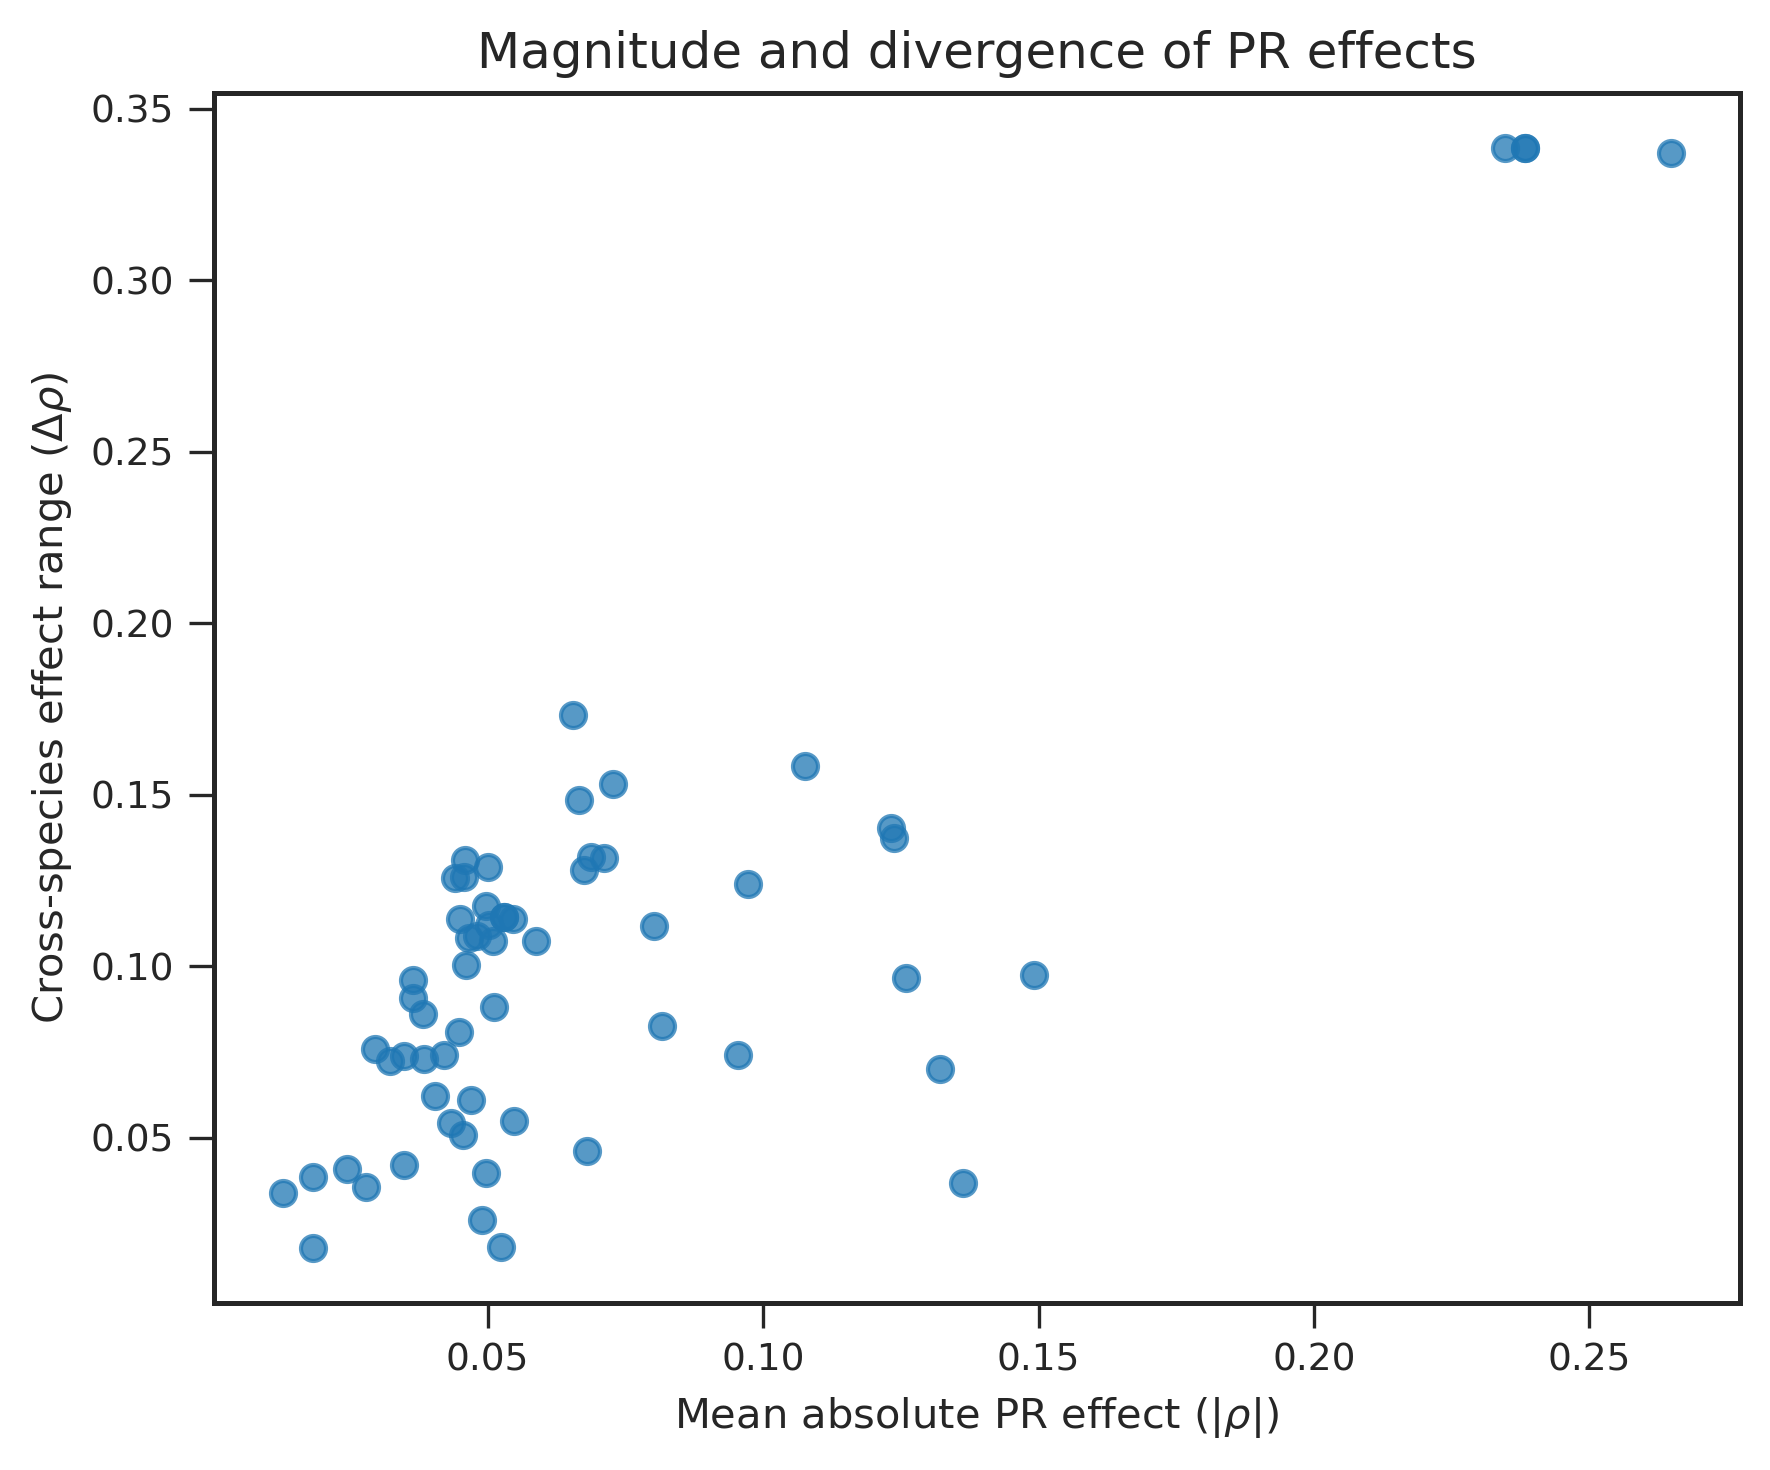

In [27]:
# ============================================
# 05. Effect magnitude vs cross-species divergence
# ============================================

effect_divergence_df["Max_abs_rho"] = (
    effect_divergence_df[SPECIES_ORDER]
    .abs()
    .max(axis=1)
)

effect_divergence_df["Mean_abs_rho"] = (
    effect_divergence_df[SPECIES_ORDER]
    .abs()
    .mean(axis=1)
)

display(
    effect_divergence_df[
        [
            "Feature", "Region", "Feature_type",
            "AT", "NB", "OS",
            "Mean_rho", "Range_rho", "SD_rho",
            "Mean_abs_rho", "Max_abs_rho",
        ]
    ]
    .sort_values("Range_rho", ascending=False)
    .round(3)
)

# --------------------------------------------
# Plot all 61 features
# --------------------------------------------

fig, ax = make_fig(w=6, h=5)

ax.scatter(
    effect_divergence_df["Mean_abs_rho"],
    effect_divergence_df["Range_rho"],
    alpha=0.75,
)

ax.set(
    xlabel=r"Mean absolute PR effect ($|\rho|$)",
    ylabel=r"Cross-species effect range ($\Delta\rho$)",
    title="Magnitude and divergence of PR effects",
)

plt.tight_layout()
plt.show()

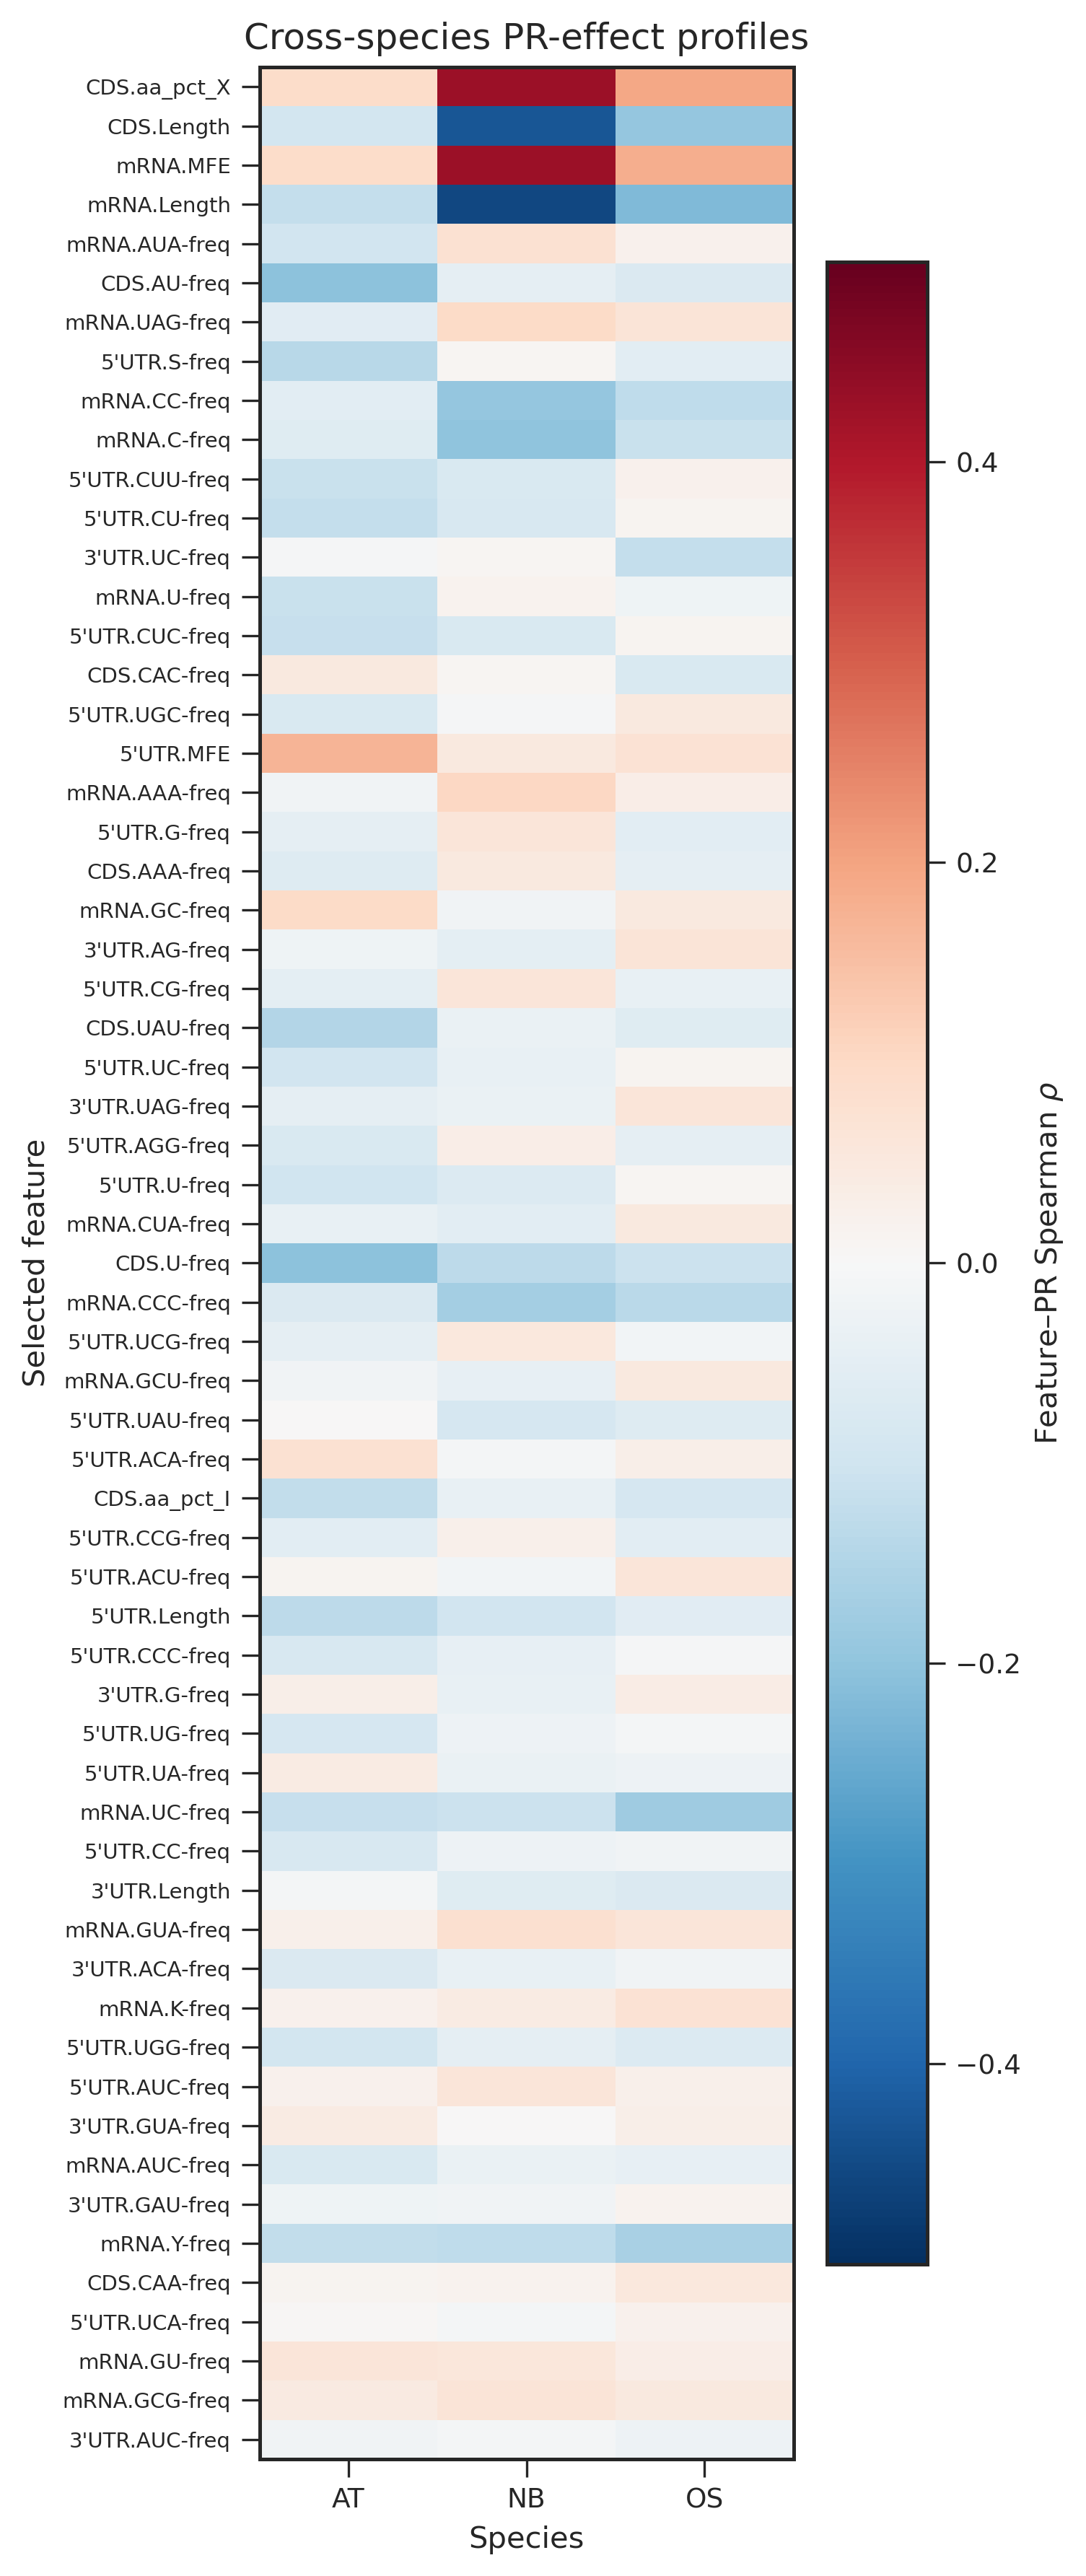

,AT,NB,OS,Mean_abs_rho,Range_rho,Region,Feature_type
Feature,,,,,,,
CDS.aa_pct_X,0.091,0.429,0.195,0.238,0.338,CDS,Amino_acid_composition
CDS.Length,-0.091,-0.429,-0.195,0.238,0.338,CDS,Length
mRNA.MFE,0.091,0.430,0.183,0.235,0.338,mRNA,RNA_structure_MFE
mRNA.Length,-0.119,-0.456,-0.220,0.265,0.337,mRNA,Length
mRNA.AUA-freq,-0.096,0.077,0.023,0.066,0.173,mRNA,Nucleotide_kmer_freq
...,...,...,...,...,...,...,...
CDS.CAA-freq,0.016,0.017,0.051,0.028,0.036,CDS,Nucleotide_kmer_freq
5'UTR.UCA-freq,0.005,-0.011,0.023,0.013,0.034,5'UTR,Nucleotide_kmer_freq
mRNA.GU-freq,0.059,0.055,0.033,0.049,0.026,mRNA,Nucleotide_kmer_freq


In [28]:
# ============================================
# 06. Cross-species PR-effect profiles
# ============================================

profile_df = effect_divergence_df.sort_values("Range_rho", ascending=False).set_index("Feature")
plot_df = profile_df[SPECIES_ORDER]

fig, ax = make_fig(w=5, h=12)
im = ax.imshow(plot_df, aspect="auto", cmap="RdBu_r", vmin=-.5, vmax=.5)

ax.set_xticks(range(3), SPECIES_ORDER)
ax.set_yticks(range(len(plot_df)), plot_df.index, fontsize=7)
ax.set_title("Cross-species PR-effect profiles")
ax.set_xlabel("Species")
ax.set_ylabel("Selected feature")

fig.colorbar(im, ax=ax, label=r"Feature–PR Spearman $\rho$")
plt.tight_layout()
plt.show()

display(
    profile_df[
        ["AT", "NB", "OS", "Mean_abs_rho", "Range_rho", "Region", "Feature_type"]
    ].round(3)
)

,N,Median_range,Mean_range,Max_range
Direction,,,,
Conserved,30,0.072,0.106,0.338
Mixed,31,0.112,0.107,0.173


,Feature,AT,NB,OS,Range_rho,Region,Feature_type
4,mRNA.AUA-freq,-0.096,0.077,0.023,0.173,mRNA,Nucleotide_kmer_freq
6,mRNA.UAG-freq,-0.056,0.097,0.065,0.153,mRNA,Nucleotide_kmer_freq
7,5'UTR.S-freq,-0.140,0.008,-0.052,0.148,5'UTR,Nucleotide_kmer_freq
10,5'UTR.CUU-freq,-0.112,-0.075,0.020,0.132,5'UTR,Nucleotide_kmer_freq
11,5'UTR.CU-freq,-0.119,-0.082,0.013,0.132,5'UTR,Nucleotide_kmer_freq
12,3'UTR.UC-freq,-0.007,0.010,-0.121,0.131,3'UTR,Nucleotide_kmer_freq
13,mRNA.U-freq,-0.110,0.019,-0.021,0.129,mRNA,Nucleotide_kmer_freq
14,5'UTR.CUC-freq,-0.115,-0.074,0.013,0.128,5'UTR,Nucleotide_kmer_freq
15,CDS.CAC-freq,0.049,0.011,-0.077,0.126,CDS,Nucleotide_kmer_freq
16,5'UTR.UGC-freq,-0.077,-0.006,0.049,0.126,5'UTR,Nucleotide_kmer_freq


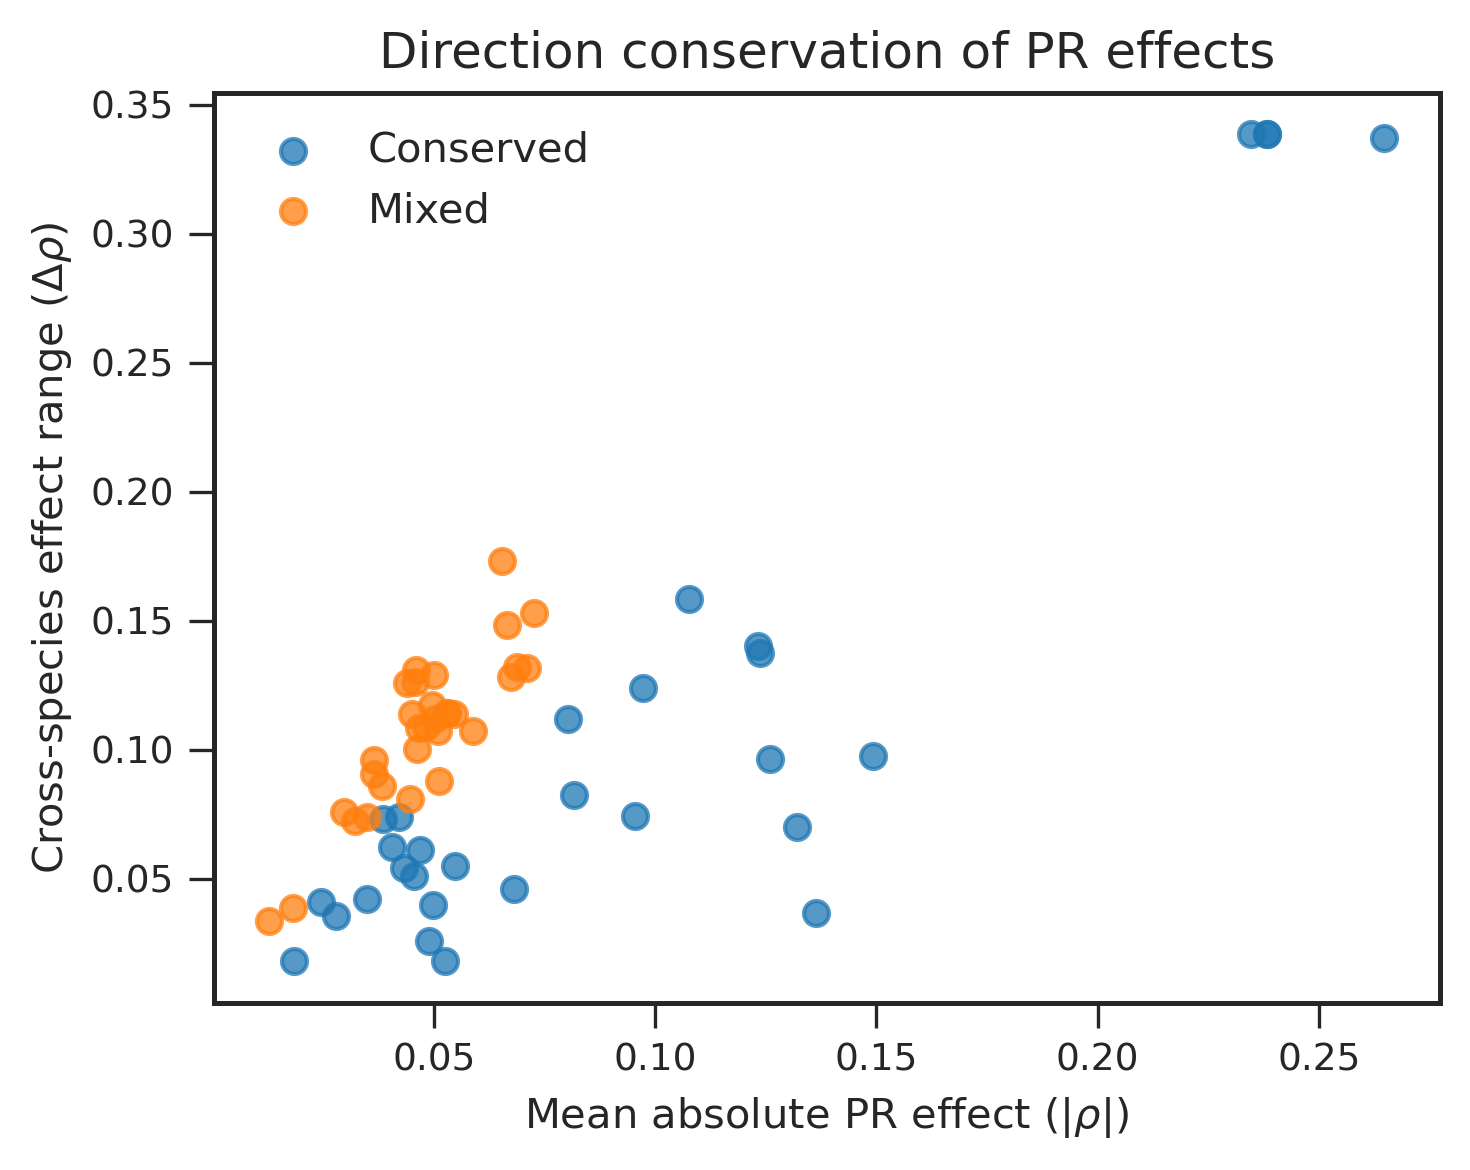

In [29]:
# ============================================
# 07. Direction conservation across species
# ============================================

sign_df = effect_divergence_df.copy()
signs = np.sign(sign_df[SPECIES_ORDER])

sign_df["N_positive"] = (signs > 0).sum(axis=1)
sign_df["N_negative"] = (signs < 0).sum(axis=1)
sign_df["Same_direction"] = (sign_df["N_positive"].eq(3) | sign_df["N_negative"].eq(3))
sign_df["Direction"] = np.where(sign_df["Same_direction"], "Conserved", "Mixed")

summary = (
    sign_df.groupby("Direction")
    .agg(N=("Feature", "size"), Median_range=("Range_rho", "median"),
         Mean_range=("Range_rho", "mean"), Max_range=("Range_rho", "max"))
    .round(3)
)

display(summary)
display(
    sign_df.loc[~sign_df["Same_direction"],
        ["Feature", "AT", "NB", "OS", "Range_rho", "Region", "Feature_type"]]
    .sort_values("Range_rho", ascending=False).round(3)
)

fig, ax = make_fig(w=5, h=4)
for name, d in sign_df.groupby("Direction"):
    ax.scatter(d["Mean_abs_rho"], d["Range_rho"], label=name, alpha=.75)

ax.set(xlabel=r"Mean absolute PR effect ($|\rho|$)",
       ylabel=r"Cross-species effect range ($\Delta\rho$)",
       title="Direction conservation of PR effects")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

,Mean_rho,Max_deviation,SD_across_species,Region,Feature_type,Selected_AT,Selected_NB,Selected_OS
Feature,,,,,,,,
mRNA.MFE,0.235,0.195,0.175,mRNA,RNA_structure_MFE,True,True,False
mRNA.Length,-0.265,0.191,0.173,mRNA,Length,False,True,True
CDS.aa_pct_X,0.238,0.191,0.173,CDS,Amino_acid_composition,False,True,False
CDS.Length,-0.238,0.191,0.173,CDS,Length,False,True,True
CDS.AU-freq,-0.108,0.097,0.085,CDS,Nucleotide_kmer_freq,True,False,False
...,...,...,...,...,...,...,...,...
3'UTR.GUA-freq,0.024,0.022,0.021,3'UTR,Nucleotide_kmer_freq,False,False,True
5'UTR.UCA-freq,0.006,0.017,0.017,5'UTR,Nucleotide_kmer_freq,True,False,False
mRNA.GU-freq,0.049,0.016,0.014,mRNA,Nucleotide_kmer_freq,False,True,False


Species,AT,NB,OS
Feature,,,
mRNA.MFE,-0.144,0.195,-0.051
mRNA.Length,0.146,-0.191,0.045
CDS.aa_pct_X,-0.148,0.191,-0.043
CDS.Length,0.148,-0.191,0.043
CDS.AU-freq,-0.097,0.061,0.037
...,...,...,...
3'UTR.GUA-freq,0.018,-0.022,0.004
5'UTR.UCA-freq,-0.001,-0.017,0.017
mRNA.GU-freq,0.010,0.006,-0.016


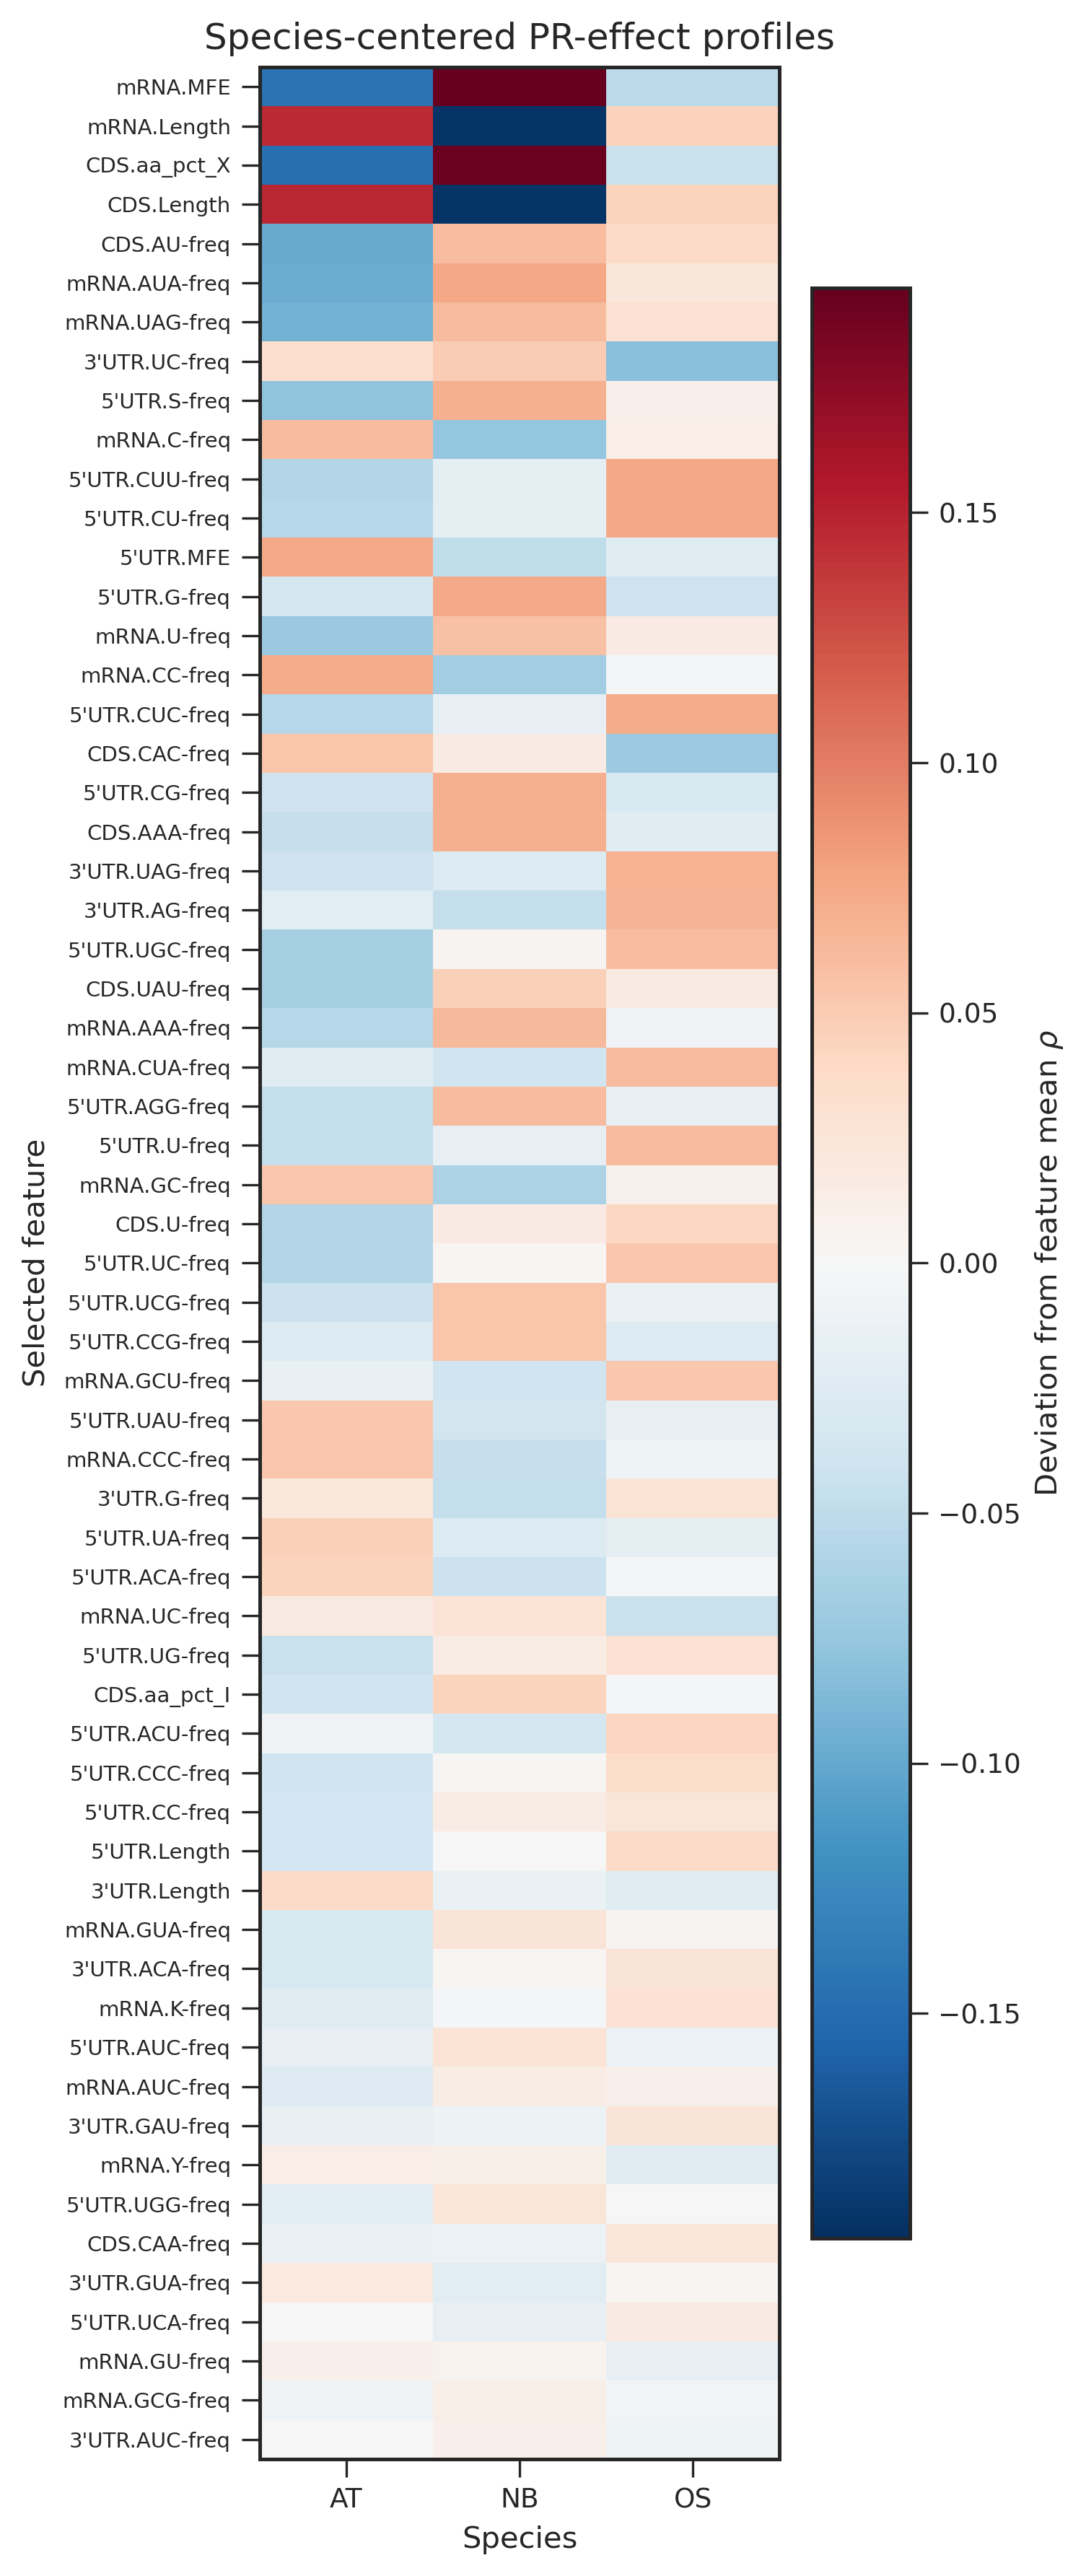

In [30]:
# ============================================
# 08. Species-centered PR-effect profiles
# ============================================

centered_matrix = spearman_matrix.sub(spearman_matrix.mean(axis=1), axis=0)

centered_summary = pd.DataFrame({
    "Mean_rho": spearman_matrix.mean(axis=1),
    "Max_deviation": centered_matrix.abs().max(axis=1),
    "SD_across_species": spearman_matrix.std(axis=1),
}).join(feature_metadata_df.set_index("Feature"))

display(centered_summary.sort_values("Max_deviation", ascending=False).round(3))
display(centered_matrix.loc[centered_summary["Max_deviation"].sort_values(ascending=False).index].round(3))

order = centered_summary["Max_deviation"].sort_values(ascending=False).index
plot_df = centered_matrix.loc[order]

fig, ax = make_fig(w=5, h=12)
v = np.abs(plot_df.to_numpy()).max()
im = ax.imshow(plot_df, aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v)

ax.set_xticks(range(3), SPECIES_ORDER)
ax.set_yticks(range(len(plot_df)), plot_df.index, fontsize=7)
ax.set(xlabel="Species", ylabel="Selected feature",
       title="Species-centered PR-effect profiles")

fig.colorbar(im, ax=ax, label=r"Deviation from feature mean $\rho$")
plt.tight_layout()
plt.show()

,k_requested,N_clusters,Silhouette,Smallest_cluster,Largest_cluster
0,2,2,0.350,16,45
1,3,3,0.397,2,43
2,4,4,0.384,2,25
3,5,5,0.420,2,25
4,6,6,0.433,2,18
5,7,7,0.438,2,18
6,8,8,0.451,2,18
7,9,9,0.448,2,14
8,10,10,0.461,2,9


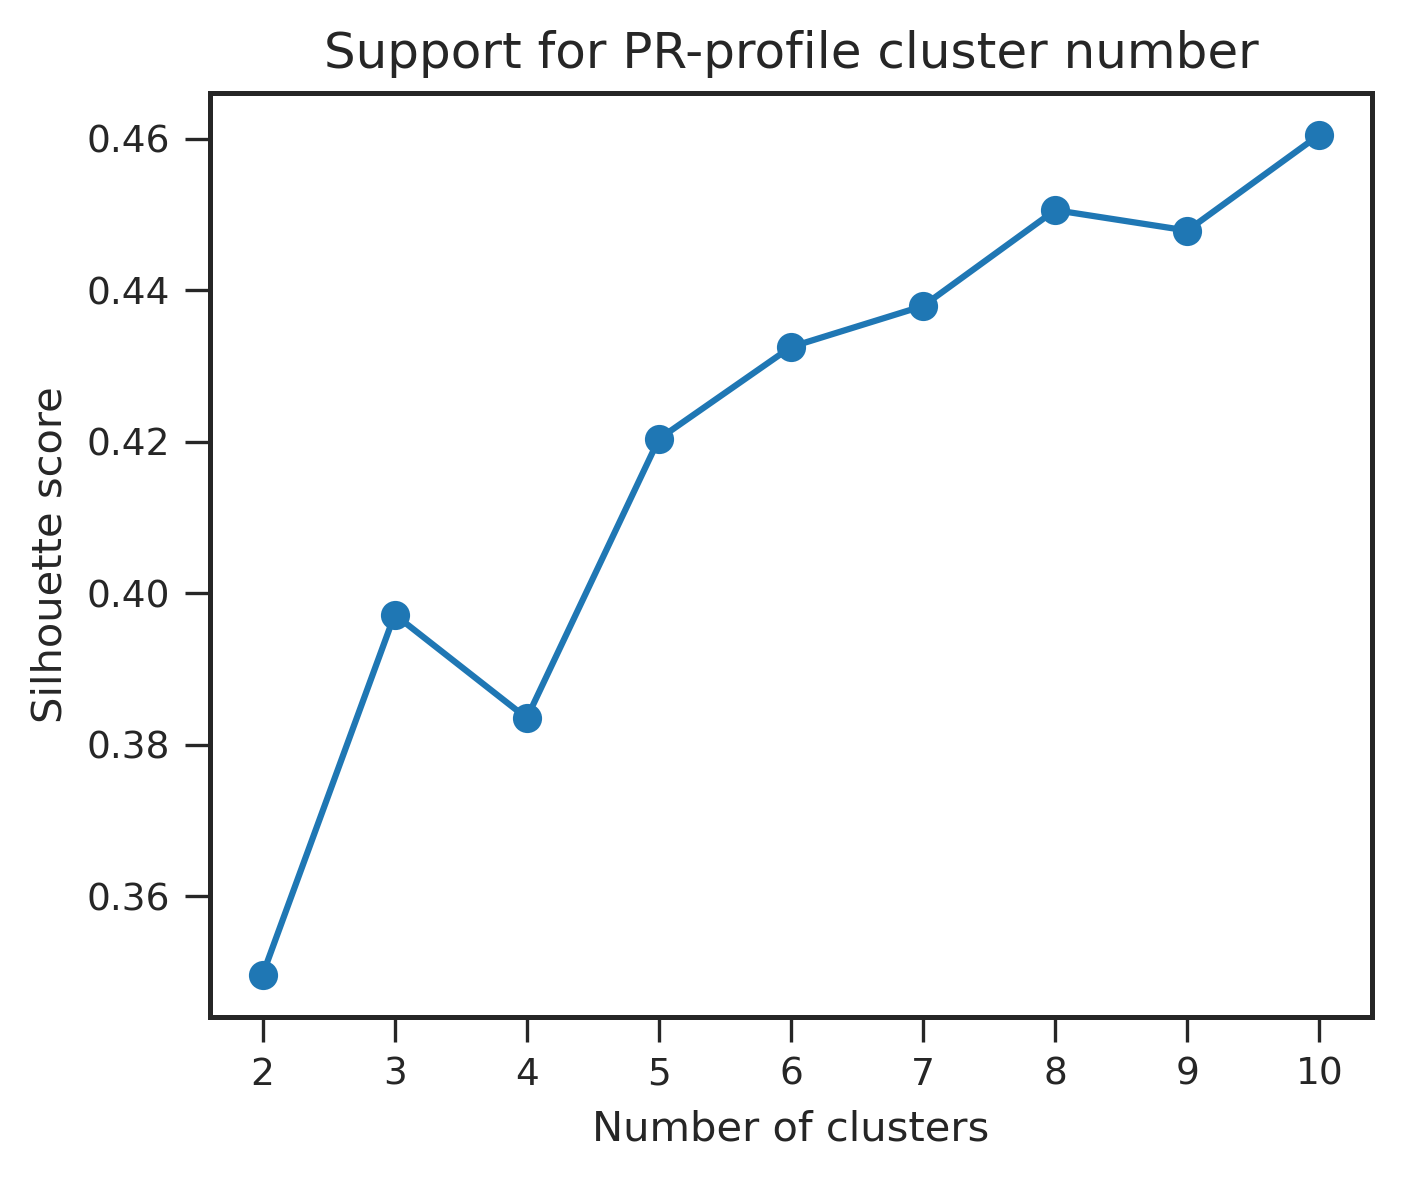

In [32]:
# ============================================
# 10. Evaluate number of PR-profile clusters
# ============================================

from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

cluster_eval = []

for k in range(2, 11):
    labels = fcluster(
        Z,
        t=k,
        criterion="maxclust",
    )

    n_clusters = len(np.unique(labels))

    # fcluster can occasionally return fewer
    # clusters than requested
    if n_clusters < 2:
        continue

    score = silhouette_score(
        X,
        labels,
        metric="euclidean",
    )

    counts = pd.Series(labels).value_counts()

    cluster_eval.append({
        "k_requested": k,
        "N_clusters": n_clusters,
        "Silhouette": score,
        "Smallest_cluster": counts.min(),
        "Largest_cluster": counts.max(),
    })

cluster_eval_df = pd.DataFrame(cluster_eval)

display(
    cluster_eval_df.round(3)
)

fig, ax = make_fig(
    w=5,
    h=4,
)

ax.plot(
    cluster_eval_df["N_clusters"],
    cluster_eval_df["Silhouette"],
    marker="o",
)

ax.set_xlabel(
    "Number of clusters"
)

ax.set_ylabel(
    "Silhouette score"
)

ax.set_title(
    "Support for PR-profile cluster number"
)

ax.set_xticks(
    cluster_eval_df["N_clusters"]
)

plt.show()

In [33]:
# ============================================
# 11. Inspect cluster-size behavior
# ============================================

display(
    cluster_eval_df[
        [
            "N_clusters",
            "Silhouette",
            "Smallest_cluster",
            "Largest_cluster",
        ]
    ].round(3)
)

,N_clusters,Silhouette,Smallest_cluster,Largest_cluster
0,2,0.350,16,45
1,3,0.397,2,43
2,4,0.384,2,25
3,5,0.420,2,25
4,6,0.433,2,18
5,7,0.438,2,18
6,8,0.451,2,18
7,9,0.448,2,14
8,10,0.461,2,9


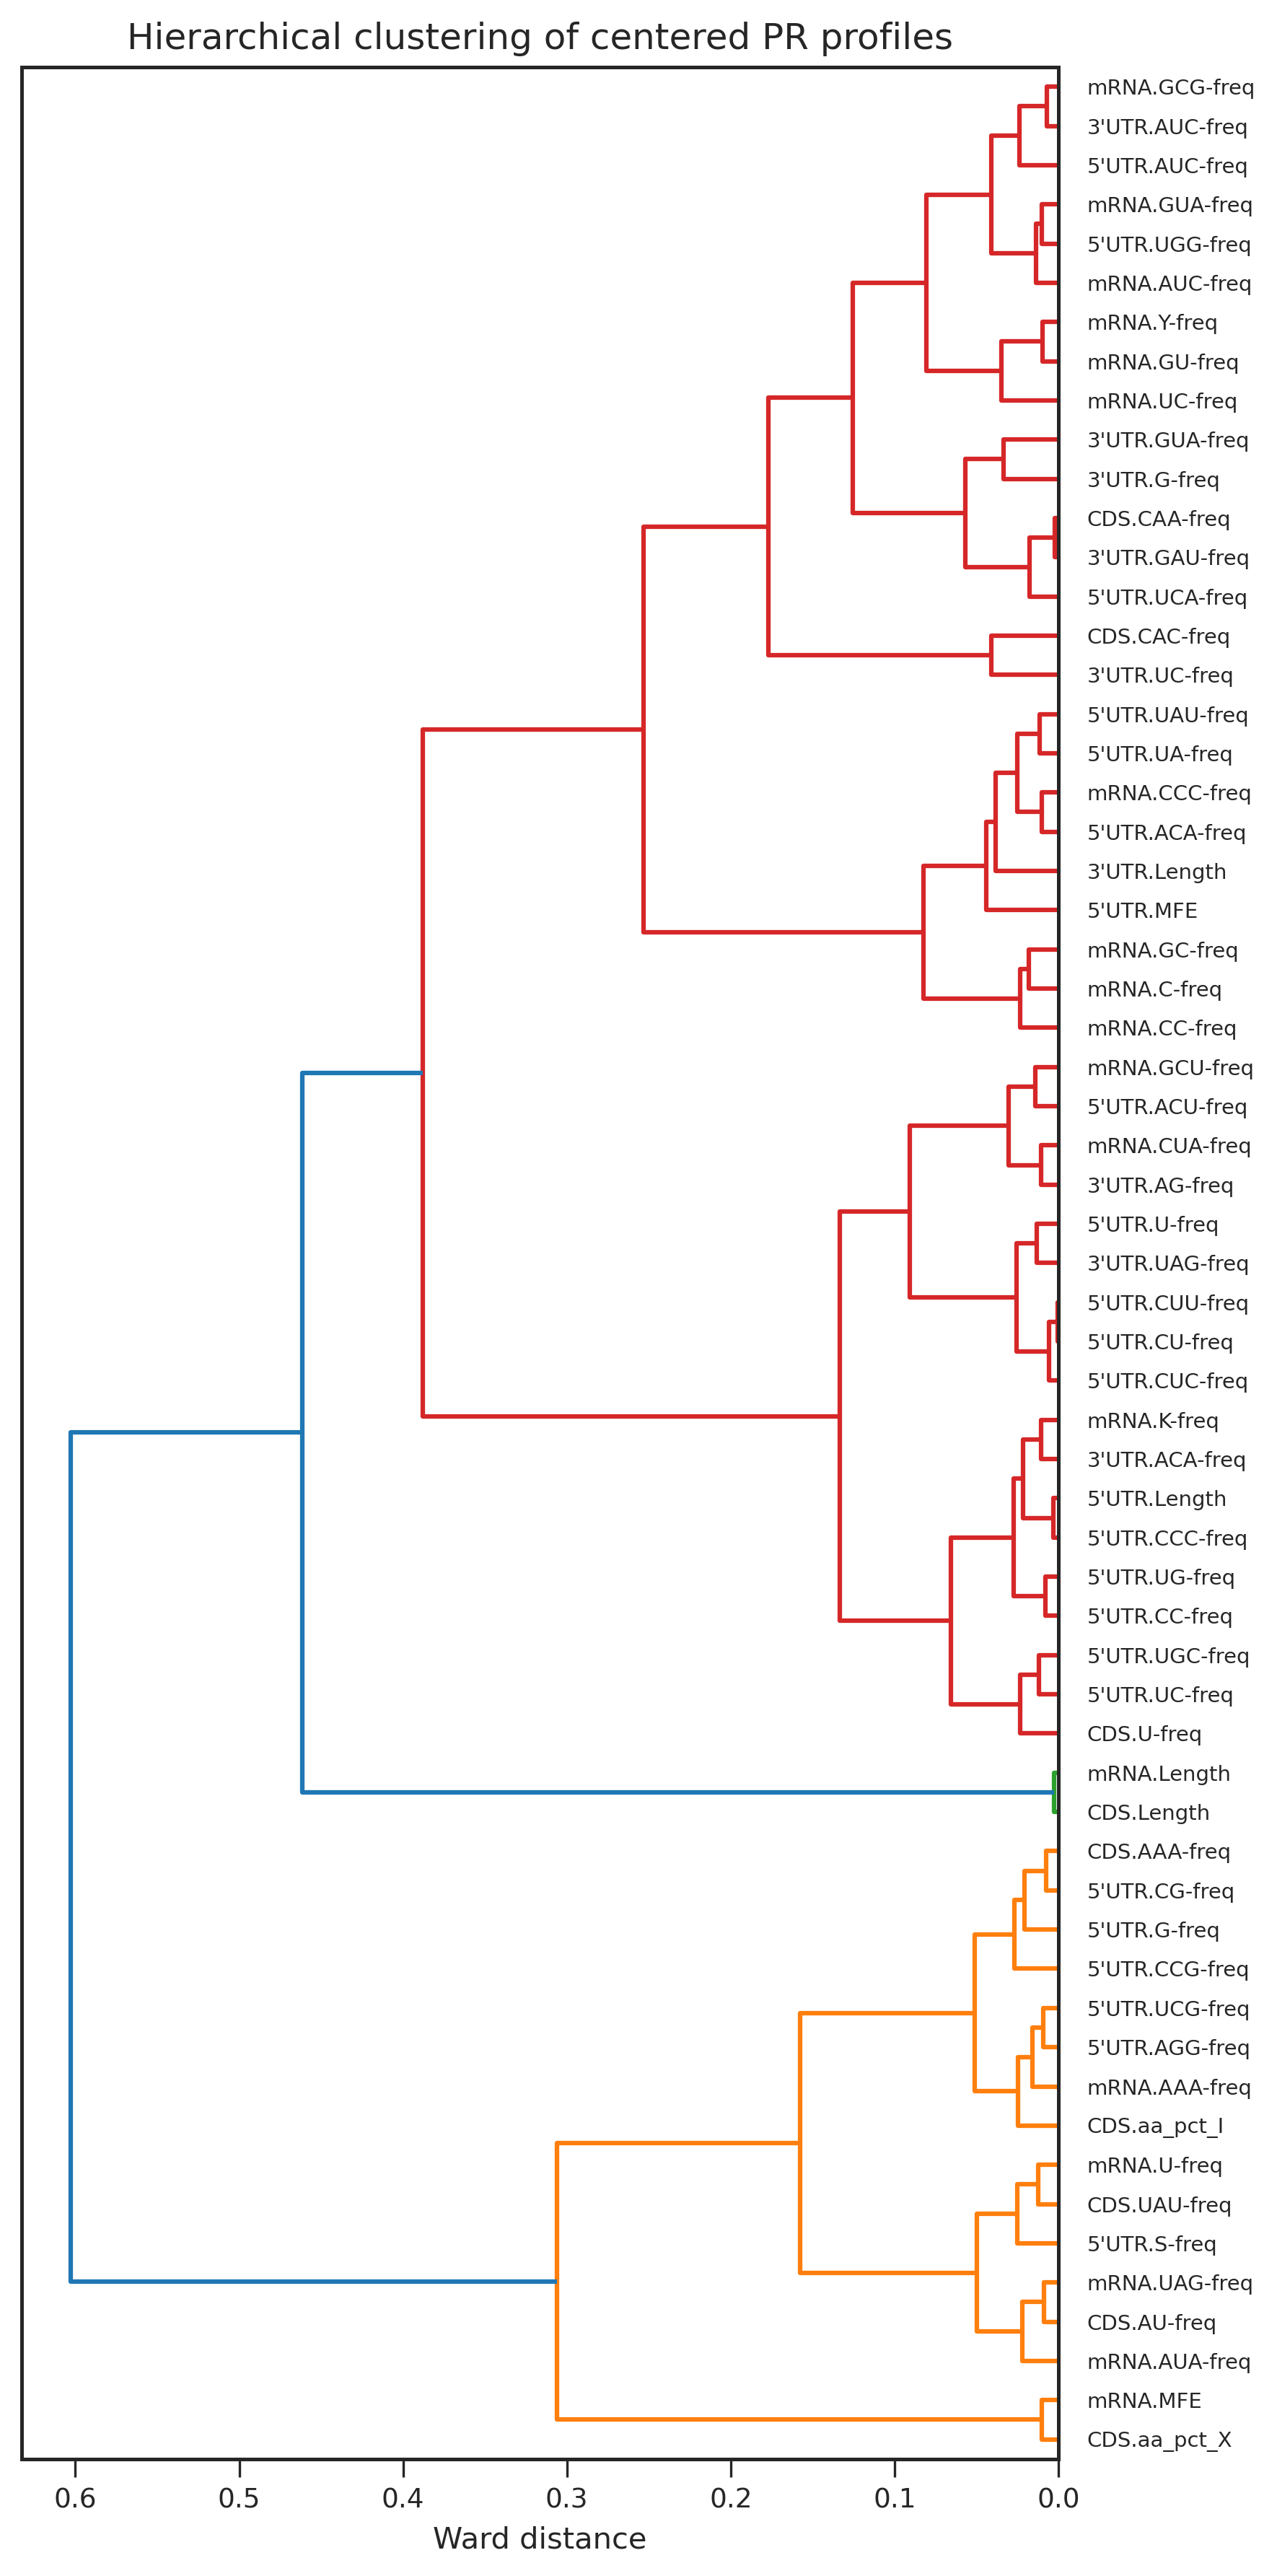

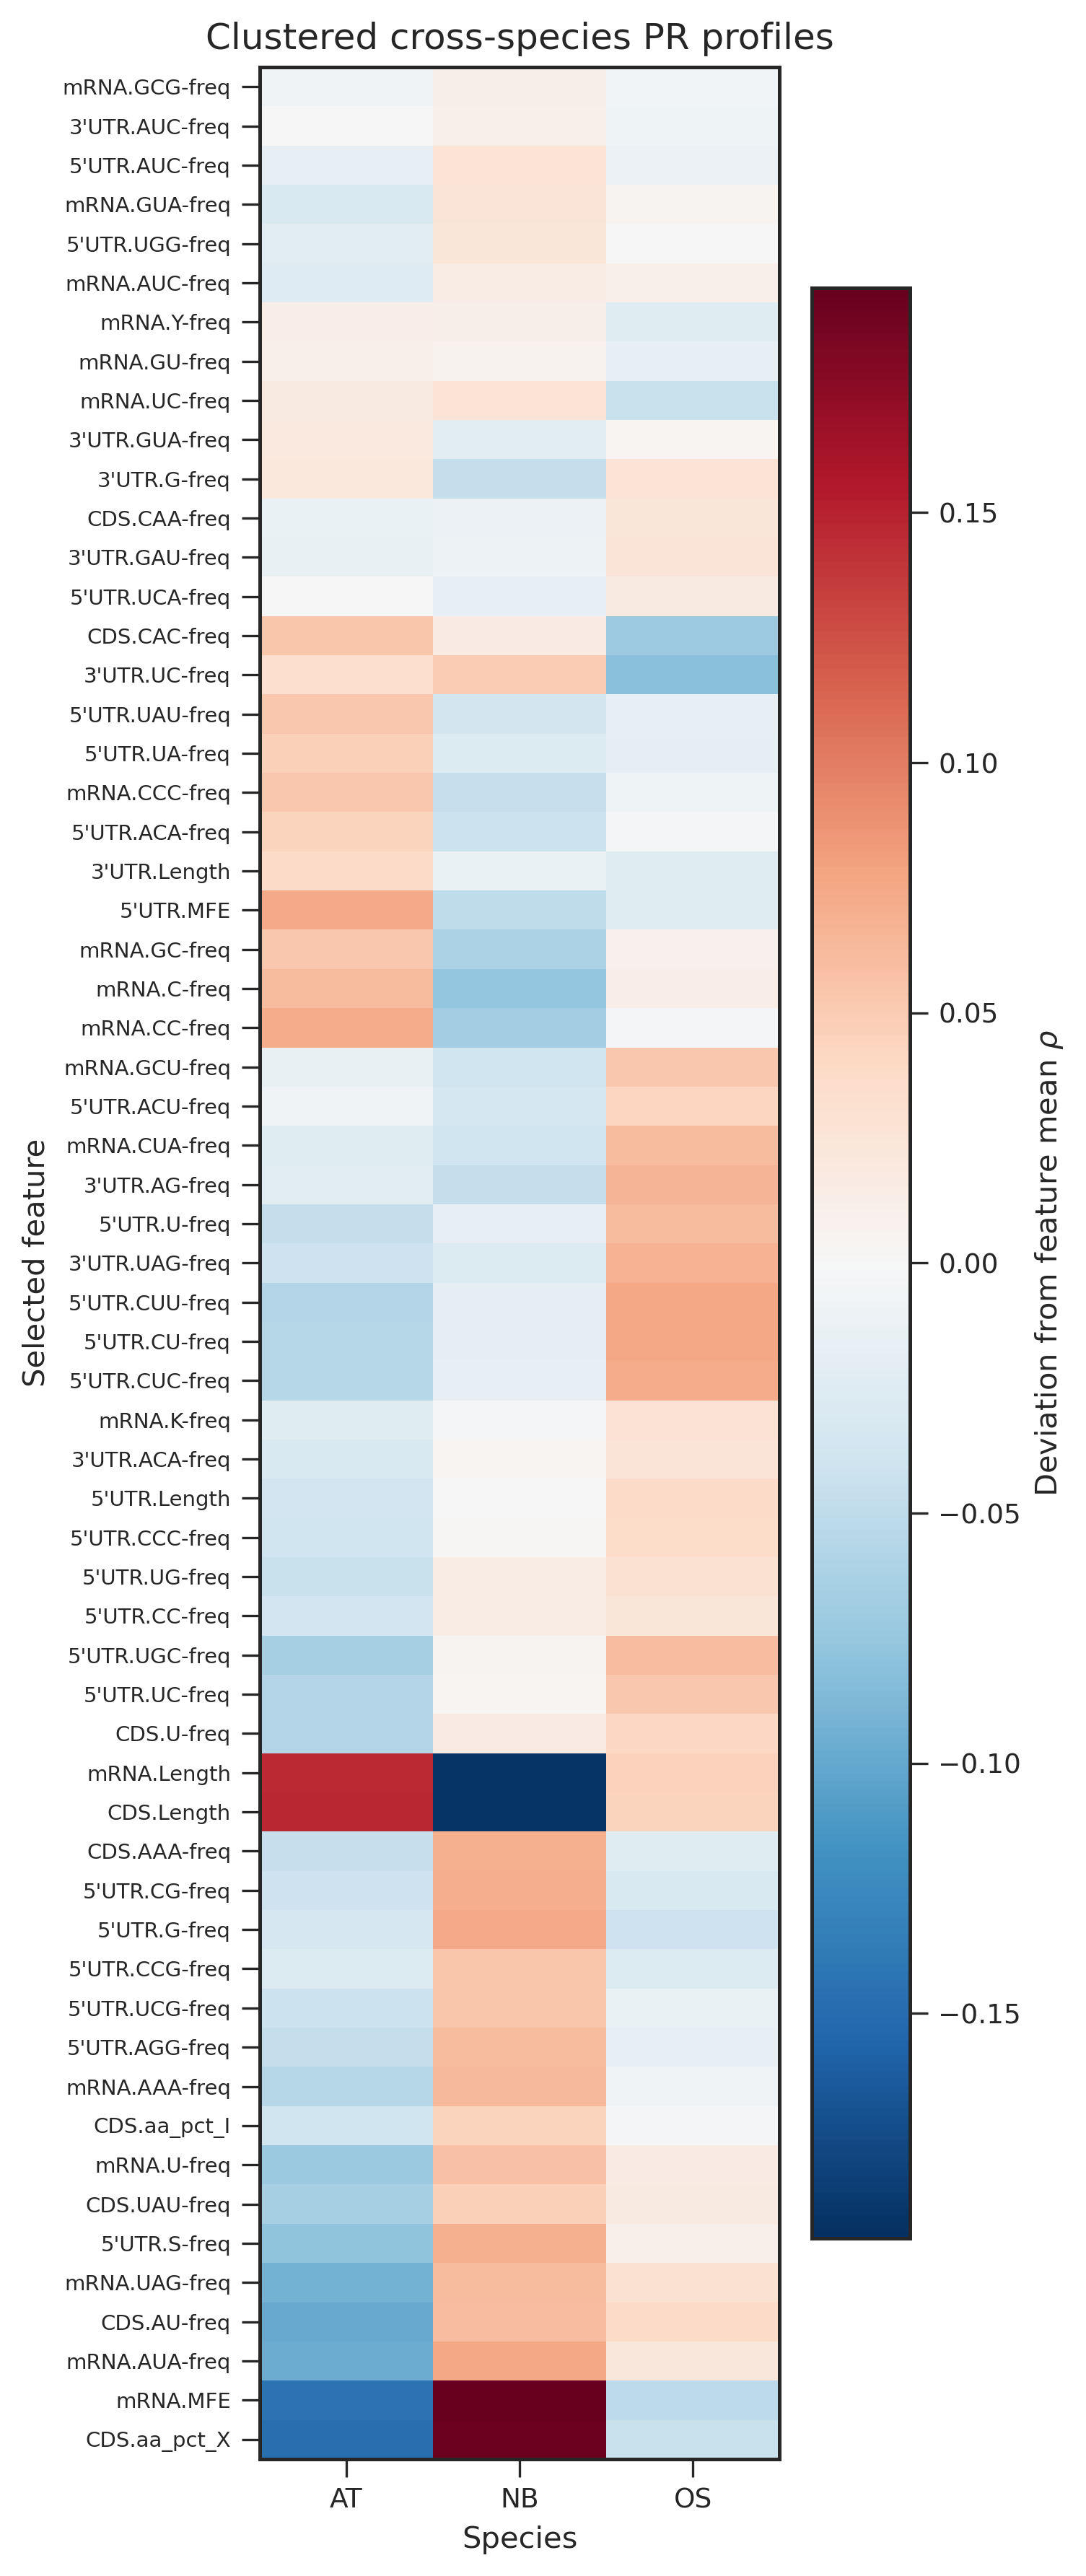

In [31]:
# ============================================
# 09. Hierarchical clustering of PR profiles
# ============================================

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

X = centered_matrix.loc[candidate_features, SPECIES_ORDER]
Z = linkage(pdist(X, metric="euclidean"), method="ward")

fig, ax = make_fig(w=6, h=12)
d = dendrogram(Z, labels=X.index, orientation="left", leaf_font_size=7, ax=ax)
ax.set(xlabel="Ward distance", title="Hierarchical clustering of centered PR profiles")
plt.tight_layout()
plt.show()

order = d["ivl"][::-1]
plot_df = X.loc[order]
v = np.abs(plot_df.to_numpy()).max()

fig, ax = make_fig(w=5, h=12)
im = ax.imshow(plot_df, aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v)
ax.set_xticks(range(3), SPECIES_ORDER)
ax.set_yticks(range(len(plot_df)), plot_df.index, fontsize=7)
ax.set(xlabel="Species", ylabel="Selected feature",
       title="Clustered cross-species PR profiles")
fig.colorbar(im, ax=ax, label=r"Deviation from feature mean $\rho$")
plt.tight_layout()
plt.show()

In [38]:
# ============================================
# 14. Characterize the k = 8 PR-profile clusters
# ============================================

k_final = 8

cluster_labels = fcluster(
    Z,
    t=k_final,
    criterion="maxclust",
)

cluster_profile_df = (
    centered_matrix
    .copy()
    .assign(Cluster=cluster_labels)
    .reset_index()
    .rename(columns={"index": "Feature"})
)

# Add original, uncentered PR effects
cluster_profile_df = (
    cluster_profile_df
    .merge(
        spearman_matrix
        .reset_index()
        .rename(columns={
            "AT": "AT_raw",
            "NB": "NB_raw",
            "OS": "OS_raw",
        }),
        on="Feature",
        how="left",
    )
)

cluster_summary = (
    cluster_profile_df
    .groupby("Cluster")
    .agg(
        N=("Feature", "size"),

        AT_centered=("AT", "mean"),
        NB_centered=("NB", "mean"),
        OS_centered=("OS", "mean"),

        AT_raw=("AT_raw", "mean"),
        NB_raw=("NB_raw", "mean"),
        OS_raw=("OS_raw", "mean"),
    )
    .reset_index()
)

display(
    cluster_summary.round(3)
)

display(
    cluster_profile_df[
        [
            "Feature",
            "Cluster",
            "AT_raw",
            "NB_raw",
            "OS_raw",
        ]
    ]
    .sort_values(
        ["Cluster", "Feature"]
    )
    .round(3)
)

,Cluster,N,AT_centered,NB_centered,OS_centered,AT_raw,NB_raw,OS_raw
0,1,2,-0.146,0.193,-0.047,0.091,0.429,0.189
1,2,6,-0.084,0.062,0.022,-0.125,0.020,-0.020
2,3,8,-0.041,0.061,-0.020,-0.059,0.043,-0.038
3,4,2,0.147,-0.191,0.044,-0.105,-0.442,-0.207
4,5,18,-0.039,-0.011,0.050,-0.076,-0.047,0.014
5,6,9,0.055,-0.046,-0.008,0.021,-0.080,-0.042
6,7,2,0.044,0.033,-0.077,0.021,0.011,-0.099
7,8,14,-0.003,0.003,0.000,-0.014,-0.007,-0.011


Species,Feature,Cluster,AT_raw,NB_raw,OS_raw
41,CDS.aa_pct_X,1,0.091,0.429,0.195
56,mRNA.MFE,1,0.091,0.430,0.183
23,5'UTR.S-freq,2,-0.140,0.008,-0.052
34,CDS.AU-freq,2,-0.205,-0.047,-0.071
39,CDS.UAU-freq,2,-0.145,-0.033,-0.062
...,...,...,...,...,...
50,mRNA.GCG-freq,8,0.046,0.064,0.047
52,mRNA.GU-freq,8,0.059,0.055,0.033
53,mRNA.GUA-freq,8,0.024,0.079,0.061
59,mRNA.UC-freq,8,-0.114,-0.106,-0.176


,k,Cluster,N,AT,NB,OS
0,5,1,2,-0.146,0.193,-0.047
1,5,2,14,-0.059,0.061,-0.002
2,5,3,2,0.147,-0.191,0.044
3,5,4,18,-0.039,-0.011,0.050
4,5,5,25,0.021,-0.012,-0.009
5,6,1,2,-0.146,0.193,-0.047
6,6,2,14,-0.059,0.061,-0.002
7,6,3,2,0.147,-0.191,0.044
8,6,4,18,-0.039,-0.011,0.050
9,6,5,9,0.055,-0.046,-0.008


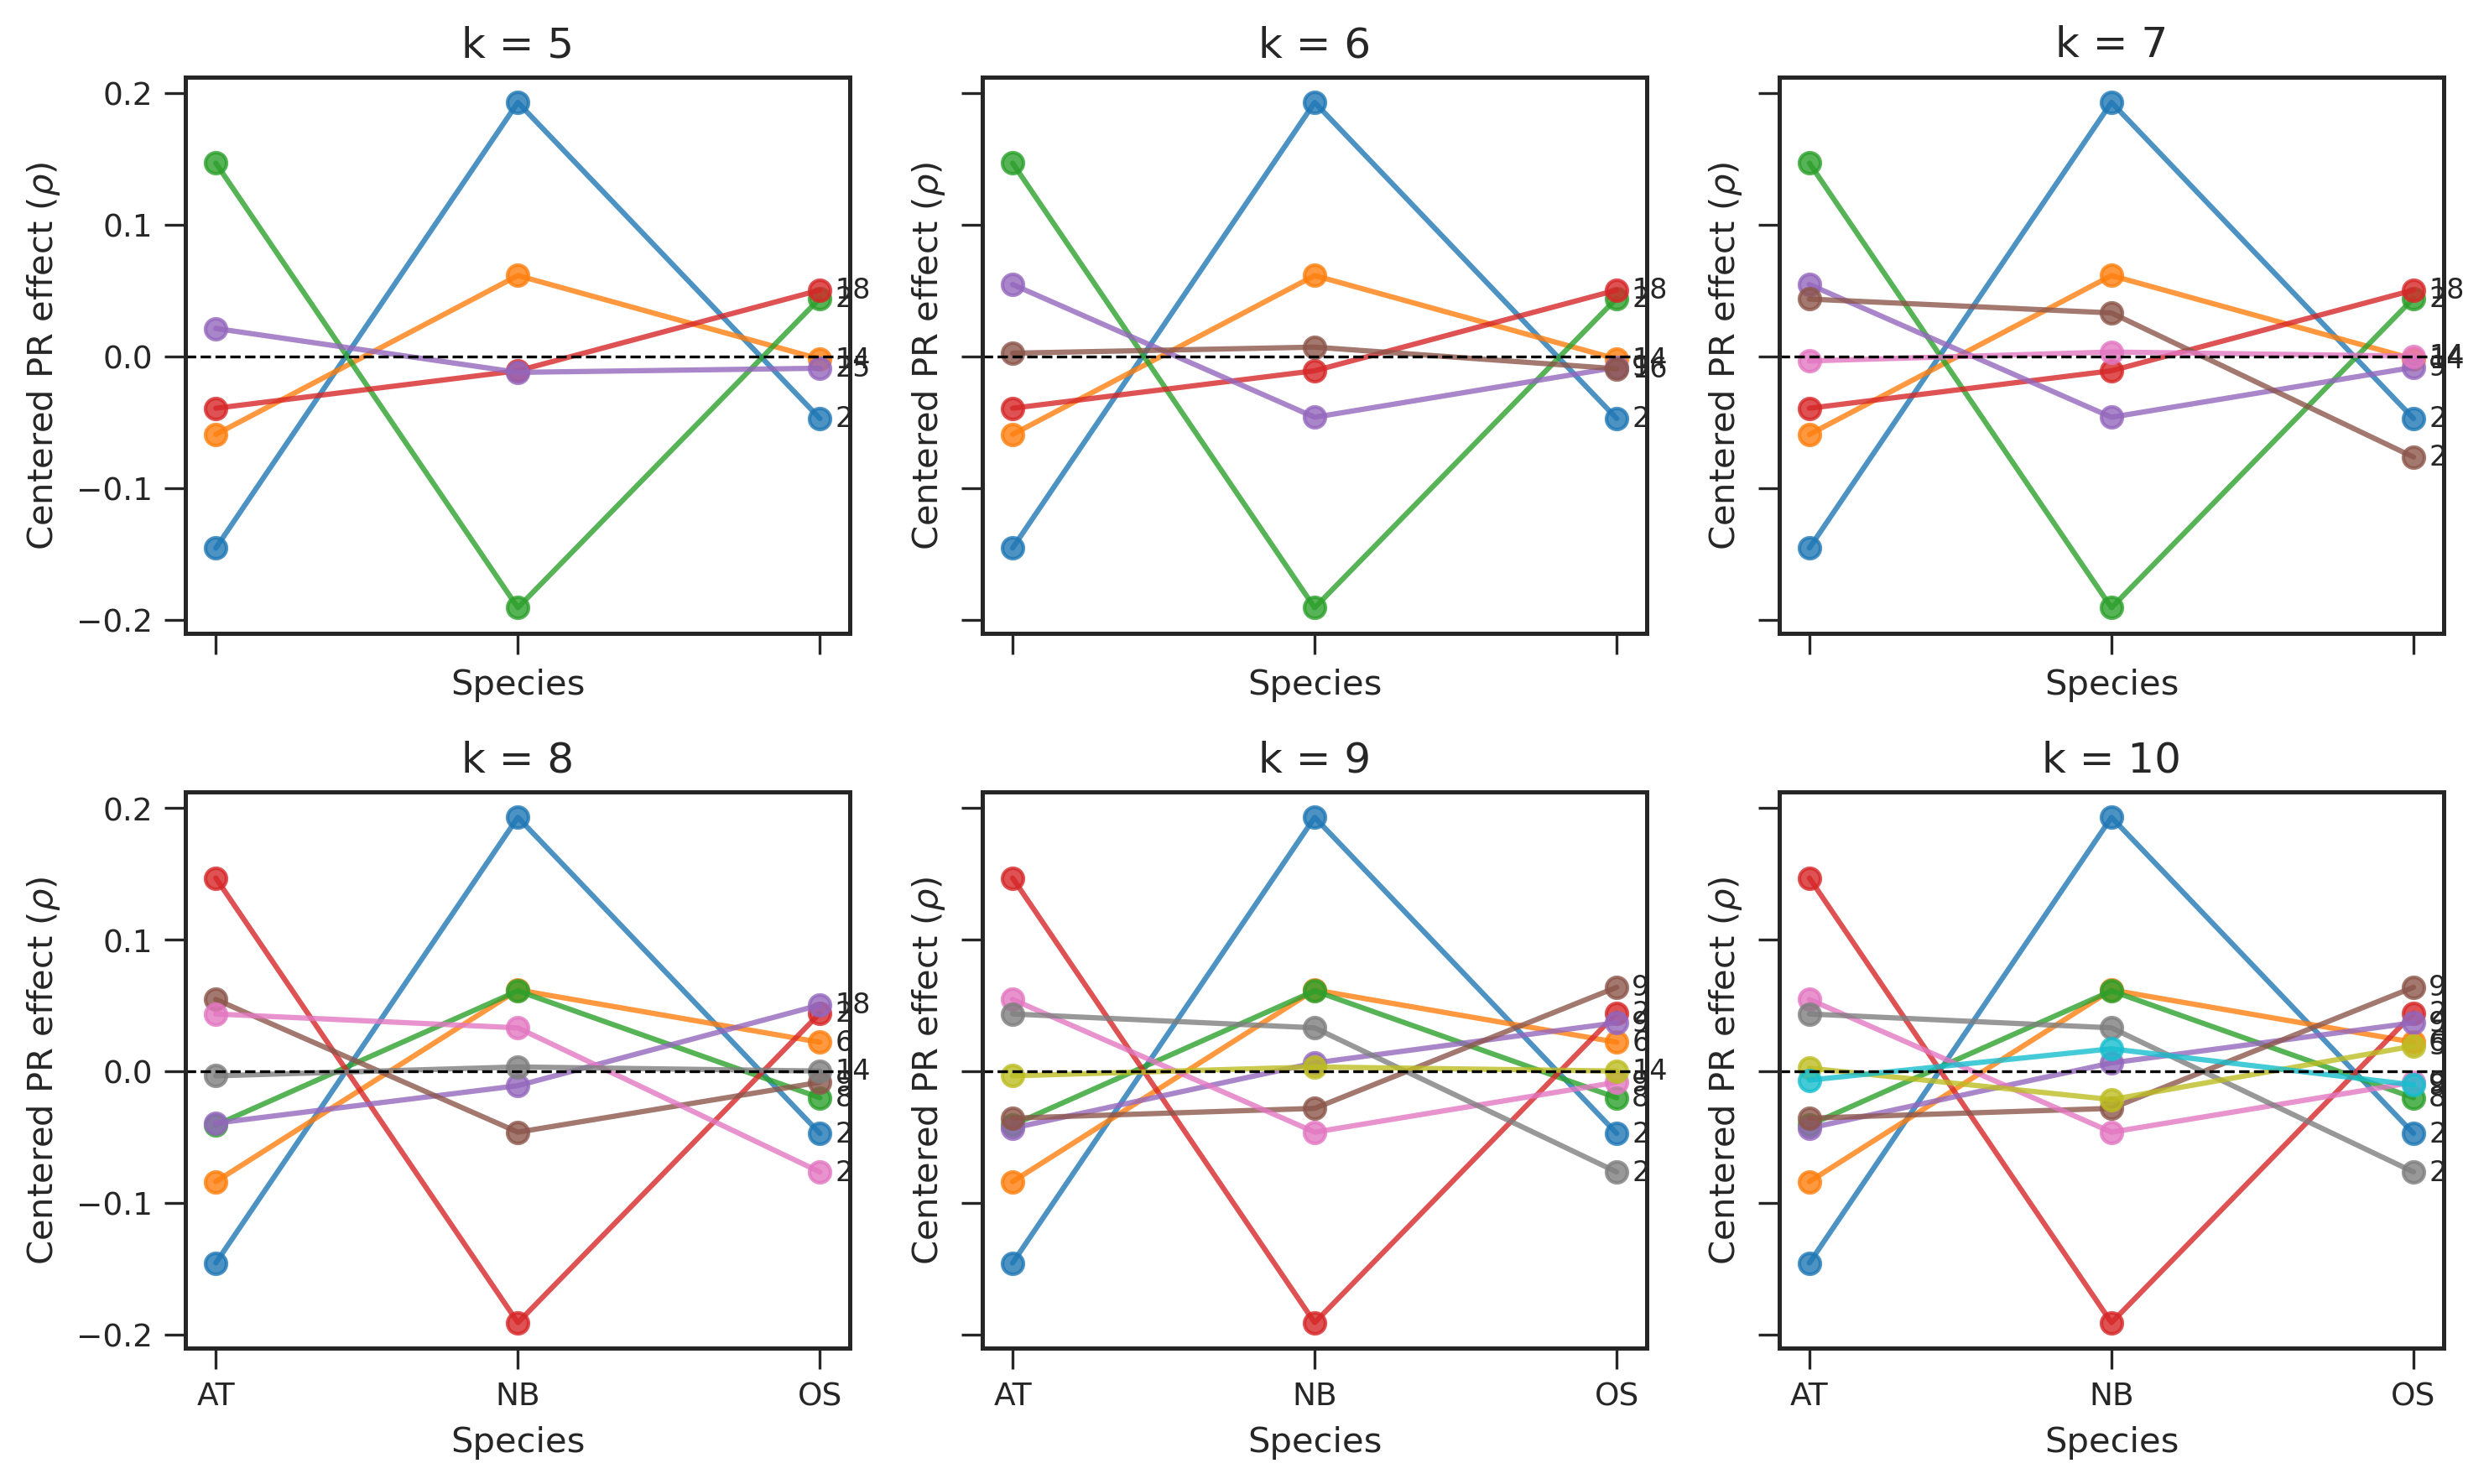

In [35]:
# ============================================
# 12. Inspect PR-profile cluster centroids
# ============================================

centroid_rows = []

for k in range(5, 11):

    labels = fcluster(
        Z,
        t=k,
        criterion="maxclust",
    )

    tmp = centered_matrix.copy()
    tmp["Cluster"] = labels

    centroids = (
        tmp
        .groupby("Cluster")[SPECIES_ORDER]
        .mean()
    )

    counts = (
        tmp["Cluster"]
        .value_counts()
        .sort_index()
    )

    for cluster_id, row in centroids.iterrows():

        centroid_rows.append({
            "k": k,
            "Cluster": cluster_id,
            "N": counts.loc[cluster_id],
            "AT": row["AT"],
            "NB": row["NB"],
            "OS": row["OS"],
        })

cluster_centroids_df = pd.DataFrame(
    centroid_rows
)

display(
    cluster_centroids_df.round(3)
)

# ============================================
# 12.1 PR-profile patterns across cluster cuts
# ============================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(10, 6),
    dpi=_PLOT_CFG["dpi"],
    sharex=True,
    sharey=True,
)

axes = axes.ravel()

for ax, k in zip(
    axes,
    range(5, 11),
):

    sub = cluster_centroids_df.loc[
        cluster_centroids_df["k"].eq(k)
    ]

    for _, row in sub.iterrows():

        ax.plot(
            SPECIES_ORDER,
            row[SPECIES_ORDER].astype(float),
            marker="o",
            linewidth=1.5,
            alpha=0.8,
        )

        ax.text(
            2.05,
            row["OS"],
            f'{int(row["N"])}',
            fontsize=8,
            va="center",
        )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8,
    )

    ax.set_title(
        f"k = {k}"
    )

    ax.set_xlabel(
        "Species"
    )

    ax.set_ylabel(
        r"Centered PR effect ($\rho$)"
    )

plt.tight_layout()
plt.show()

In [37]:
# ============================================
# 13. Track cluster splitting from k = 8 to 10
# ============================================

cluster_transition_df = pd.DataFrame(
    index=centered_matrix.index
)

for k in [8, 9, 10]:
    cluster_transition_df[f"k{k}"] = fcluster(
        Z,
        t=k,
        criterion="maxclust",
    )

# How k = 8 clusters split at k = 9
split_8_to_9 = pd.crosstab(
    cluster_transition_df["k8"],
    cluster_transition_df["k9"],
)

# How k = 9 clusters split at k = 10
split_9_to_10 = pd.crosstab(
    cluster_transition_df["k9"],
    cluster_transition_df["k10"],
)

print("k = 8 -> k = 9")
display(split_8_to_9)

print("k = 9 -> k = 10")
display(split_9_to_10)

# ============================================
# 13.1 Features involved in later splits
# ============================================

cluster_transition_df = (
    cluster_transition_df
    .reset_index()
    .rename(columns={"index": "Feature"})
)

display(
    cluster_transition_df
    .sort_values(["k8", "k9", "k10", "Feature"])
)

k = 8 -> k = 9


k9,1,2,3,4,5,6,7,8,9
k8,,,,,,,,,
1,2,0,0,0,0,0,0,0,0
2,0,6,0,0,0,0,0,0,0
3,0,0,8,0,0,0,0,0,0
4,0,0,0,2,0,0,0,0,0
5,0,0,0,0,9,9,0,0,0
6,0,0,0,0,0,0,9,0,0
7,0,0,0,0,0,0,0,2,0
8,0,0,0,0,0,0,0,0,14


k = 9 -> k = 10


k10,1,2,3,4,5,6,7,8,9,10
k9,,,,,,,,,,
1,2,0,0,0,0,0,0,0,0,0
2,0,6,0,0,0,0,0,0,0,0
3,0,0,8,0,0,0,0,0,0,0
4,0,0,0,2,0,0,0,0,0,0
5,0,0,0,0,9,0,0,0,0,0
6,0,0,0,0,0,9,0,0,0,0
7,0,0,0,0,0,0,9,0,0,0
8,0,0,0,0,0,0,0,2,0,0
9,0,0,0,0,0,0,0,0,5,9


,Feature,k8,k9,k10
41,CDS.aa_pct_X,1,1,1
56,mRNA.MFE,1,1,1
23,5'UTR.S-freq,2,2,2
34,CDS.AU-freq,2,2,2
39,CDS.UAU-freq,2,2,2
...,...,...,...,...
50,mRNA.GCG-freq,8,9,10
52,mRNA.GU-freq,8,9,10
53,mRNA.GUA-freq,8,9,10
59,mRNA.UC-freq,8,9,10


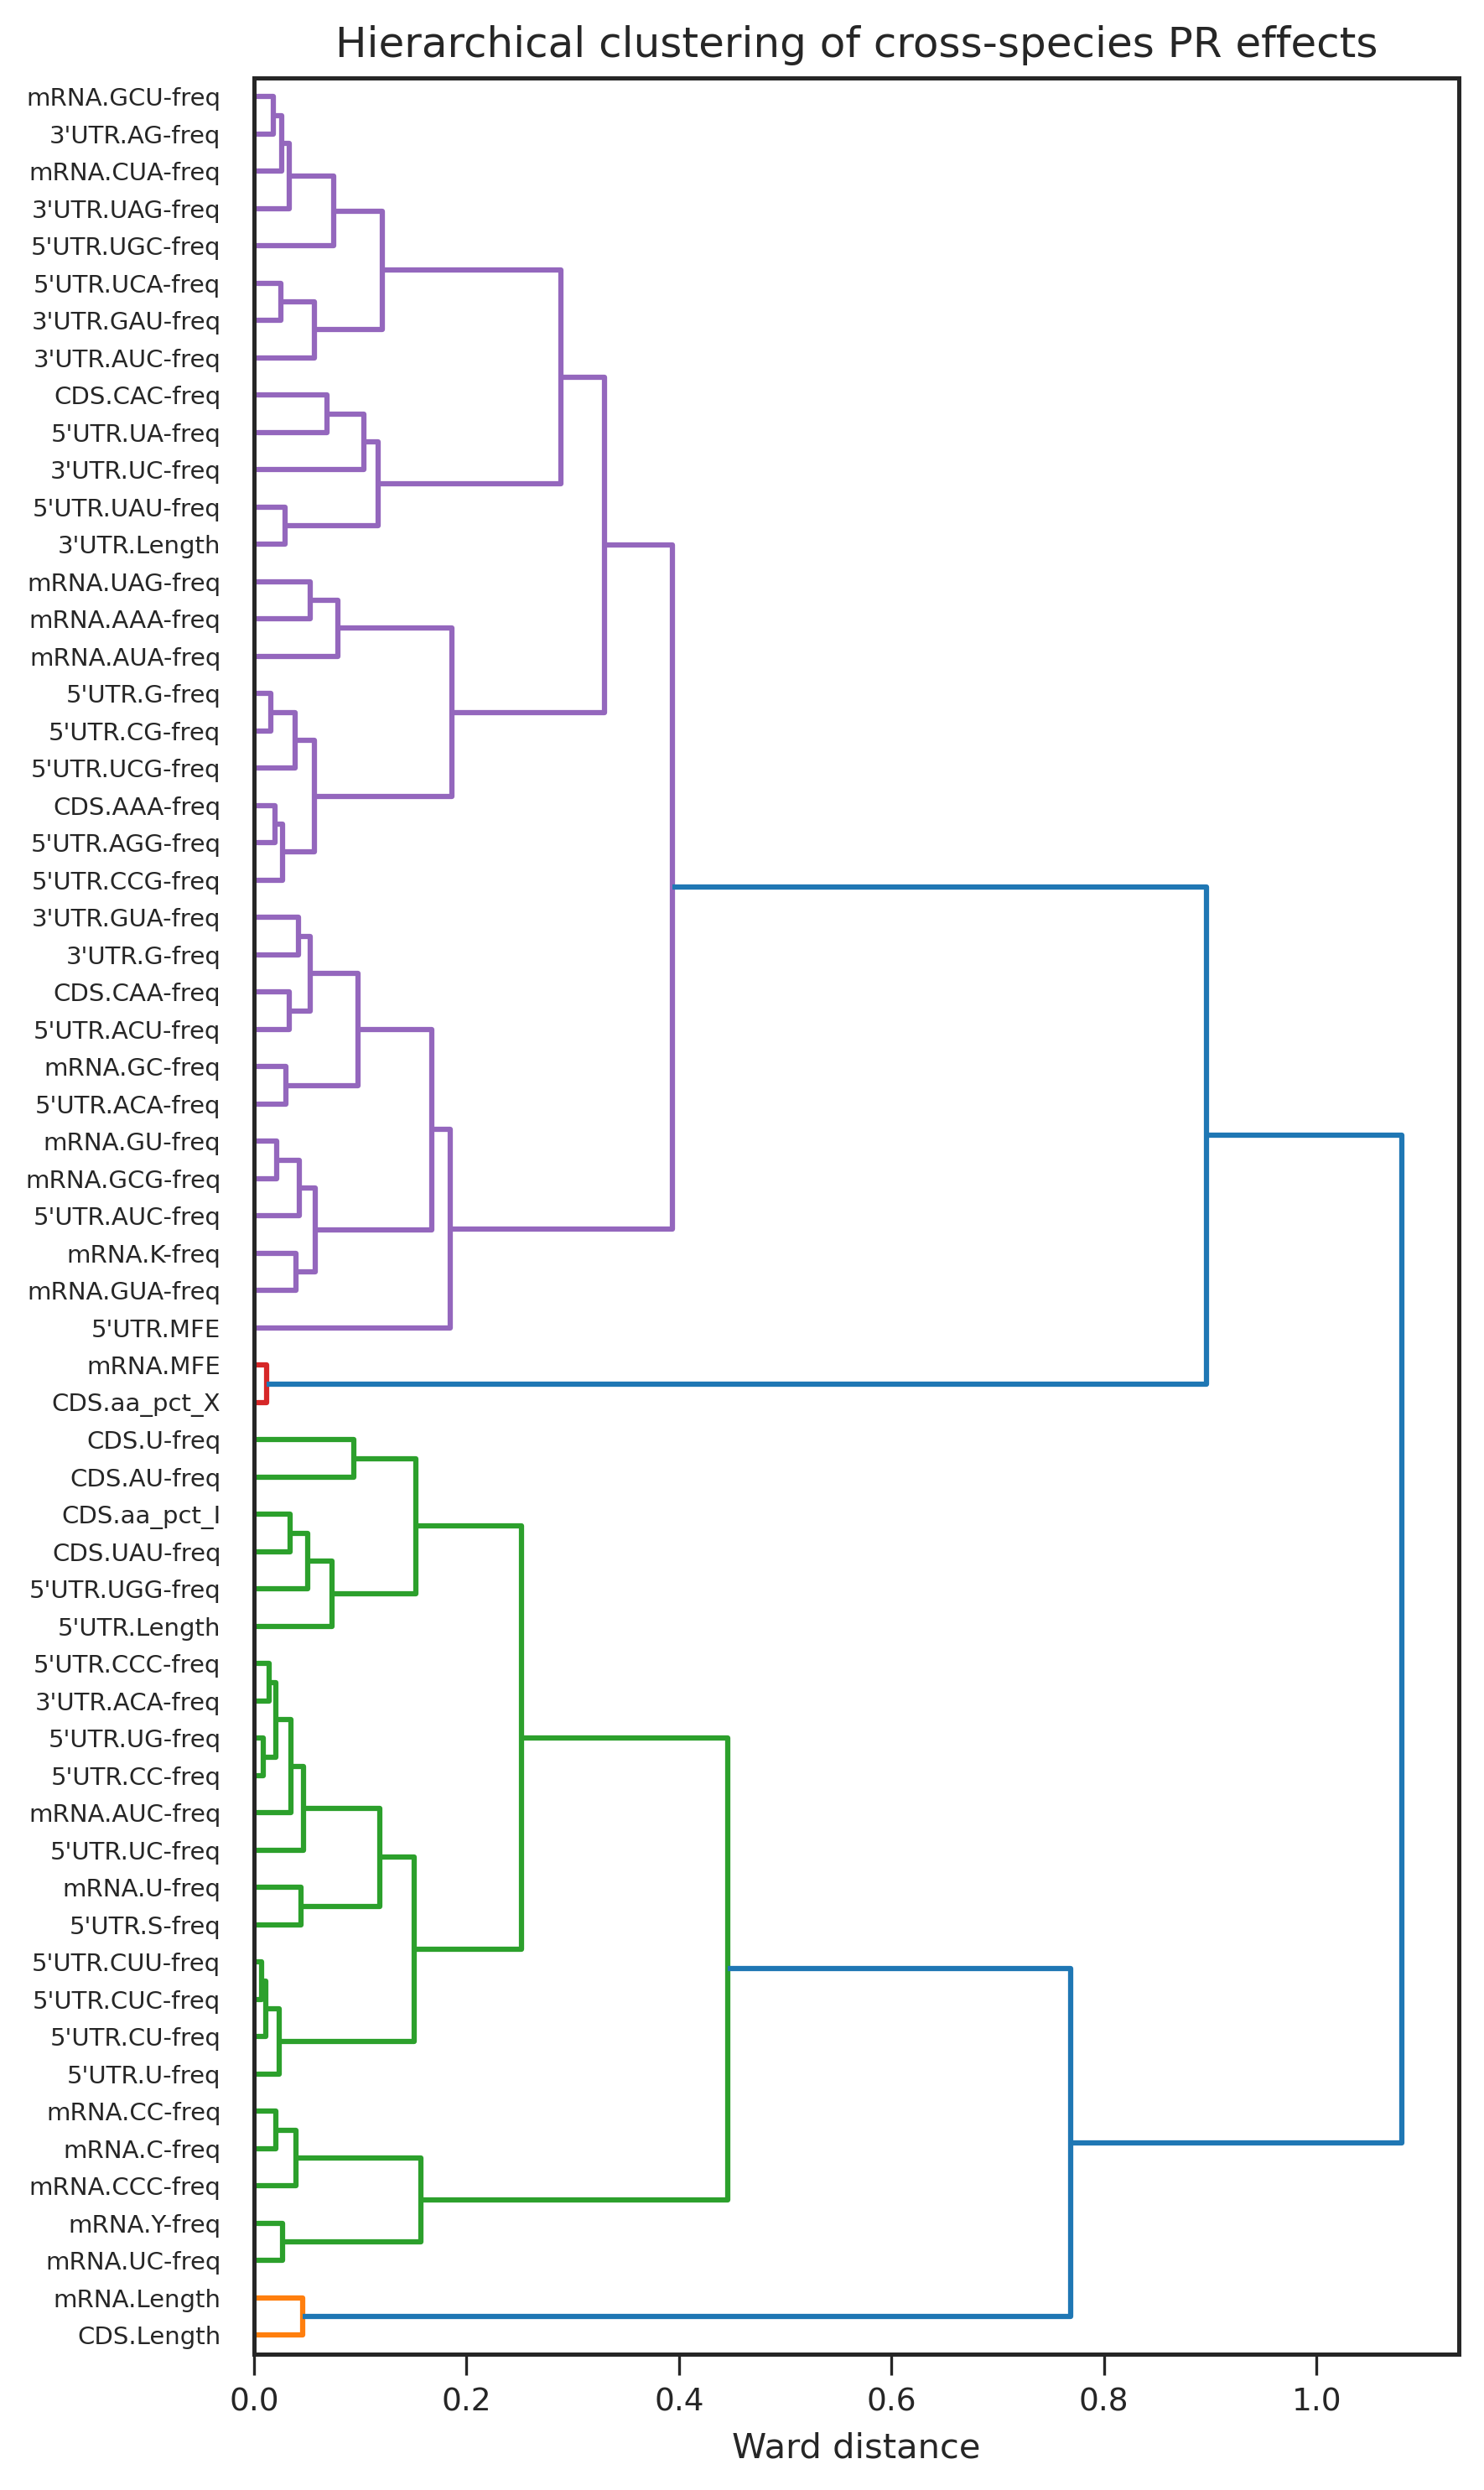

Features clustered: 61


In [9]:
# ============================================
# 04. Hierarchical clustering of PR effects
# ============================================

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

# Feature × species PR-effect matrix
cluster_matrix = (
    spearman_matrix[SPECIES_ORDER]
    .astype(float)
    .dropna()
)

# Euclidean distance + Ward linkage
distance_matrix = pdist(cluster_matrix, metric="euclidean")
linkage_matrix = linkage(distance_matrix, method="ward")

# Dendrogram
fig, ax = make_fig(w=6, h=10)

dendro = dendrogram(
    linkage_matrix,
    labels=cluster_matrix.index,
    orientation="right",
    leaf_font_size=7,
    ax=ax,
)

ax.set(
    xlabel="Ward distance",
    ylabel="",
    title="Hierarchical clustering of cross-species PR effects",
)

plt.tight_layout()
plt.show()

print("Features clustered:", len(cluster_matrix))

,K,Silhouette,Smallest_cluster,Largest_cluster
0,2,0.308252,25,36
1,3,0.349115,2,34
2,4,0.376104,2,34
3,5,0.362033,2,34
4,6,0.316127,2,22
5,7,0.351114,2,18
6,8,0.358682,2,18
7,9,0.362564,2,12
8,10,0.368267,2,12


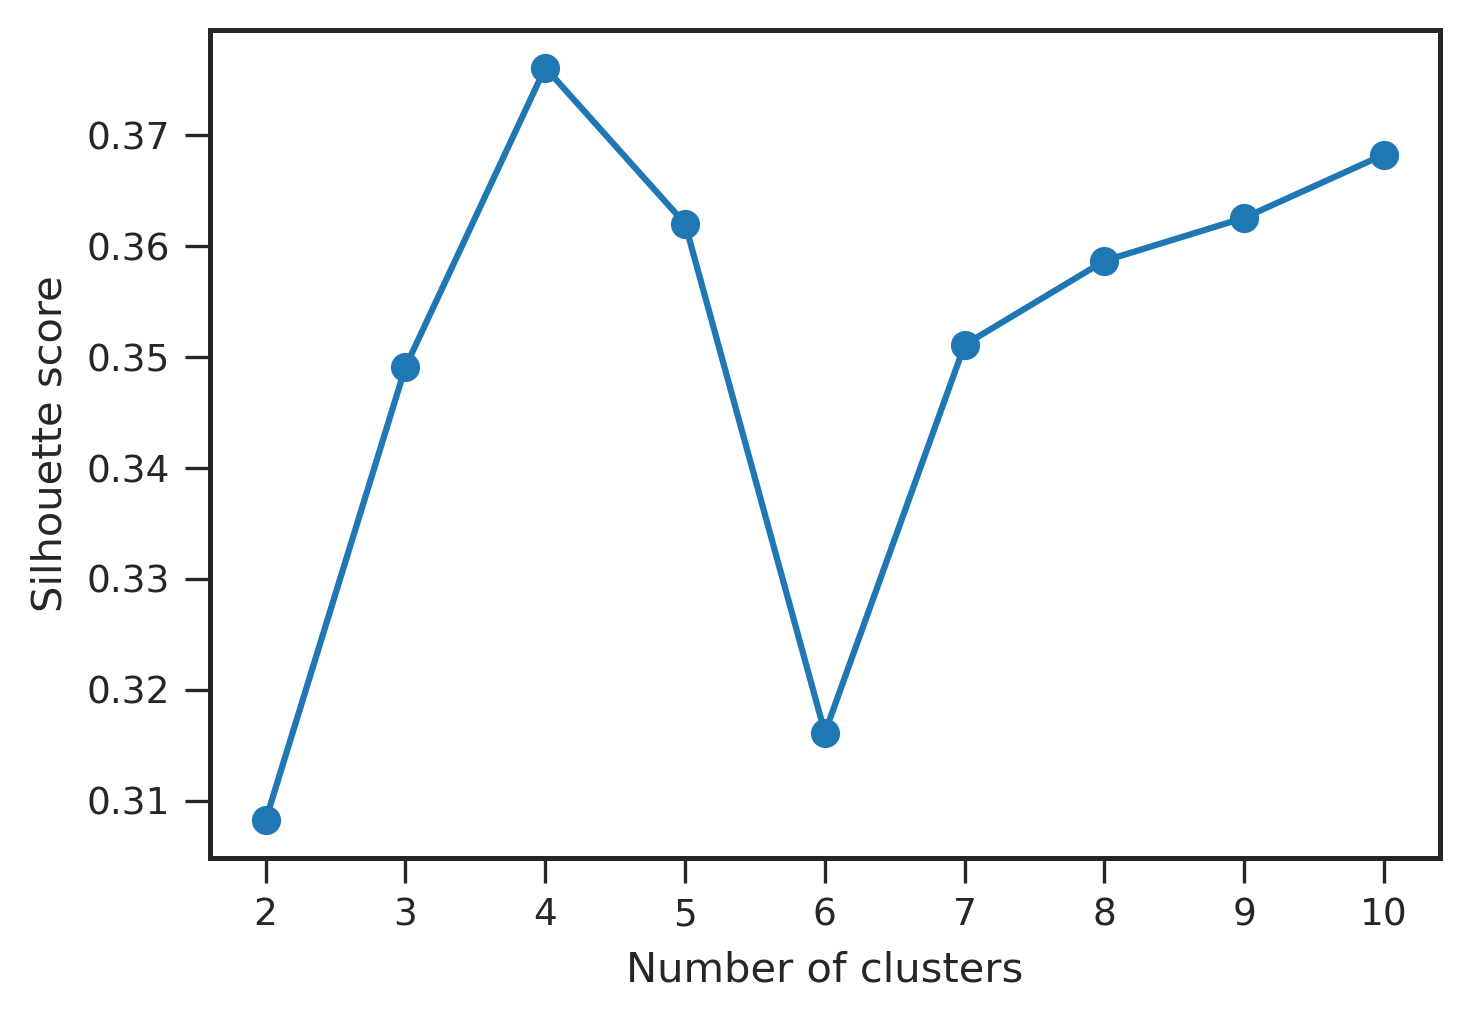

In [10]:
# ============================================
# 05. Evaluate number of PR-effect clusters
# ============================================

from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

cluster_eval = []

for k in range(2, 11):
    labels = fcluster(linkage_matrix, k, criterion="maxclust")
    cluster_eval.append({
        "K": k,
        "Silhouette": silhouette_score(cluster_matrix, labels),
        "Smallest_cluster": pd.Series(labels).value_counts().min(),
        "Largest_cluster": pd.Series(labels).value_counts().max(),
    })

cluster_eval_df = pd.DataFrame(cluster_eval)
display(cluster_eval_df)

fig, ax = make_fig(w=5, h=3.5)
ax.plot(cluster_eval_df["K"], cluster_eval_df["Silhouette"], marker="o")
ax.set(xlabel="Number of clusters", ylabel="Silhouette score")
ax.set_xticks(cluster_eval_df["K"])

plt.tight_layout()
plt.show()